# Group Project – Time Series and Data Analysis
**Part 1.** Time Series Analysis of Hanoi (Food) CPI Data  &nbsp;|&nbsp; **Part 2.** Detecting Anomalies and Change Points in Time Series of Asian Economic Data (Myanmar)

This notebook follows the structure of the *Group Project Template 2026* step by step (1.1 → 1.7 and 2.1 → 2.3). Every step contains **Code → Result → Comment**, and each series required by the template has its own cell.

**How to run:** Runtime → Run all (Google Colab or local Jupyter). Upload `Data01_01_FoodCPI.csv` and `Data02_01_Myanmar_C.csv` next to the notebook (or into `/content`). All tables are saved to `results/`, all figures to `figures/`.

### Design choices that differ from a "plain" run (and why)
| Topic | Choice | Reason |
|---|---|---|
| Constant term | ARIMA/SARIMA use a constant (`trend='c'`) for Series 1 and none (`trend='n'`) for Series 3 – decided by a t-test of *mean = 0* | Series 1 has mean ≈ 100; Series 3 has mean ≈ 0. `SARIMAX` has **no constant by default**, which would silently change the model between Sections 1.4 and 1.7 |
| Stability of parameters | A model is "stable" if the 95 % CI of **every AR / MA / constant** coefficient excludes 0 (`sigma2` is a variance, not a regression parameter, and is not tested) | Matches the template wording "check the stability of estimated regression parameters by examining the confidence intervals" |
| Convergence | Read from `mle_retvals['converged']` (not assumed). Non-converged fits are never selected | A fit that raises no exception is not necessarily a converged fit |
| SARIMA | `enforce_stationarity=True`, `enforce_invertibility=True` (statsmodels defaults) | Switching them off allows unit-root fits with meaningless AIC |
| Baselines | Every RMSE is compared with naive forecasts (train mean, last value) | RMSE alone does not show whether a model is useful |
| Missing data (Part 2) | Dropped **per series**, never imputed; gaps are shown as gaps in plots | `mil` is missing 7 years; interpolation would invent data |

### Assumptions to confirm against the course slides
These values are the usual course settings but are **parameters**, so they can be changed in one place (next cell) if the slides say otherwise.

| Parameter | Value | Where used |
|---|---|---|
| `ALPHA` | 0.05 | all tests / CIs |
| `NLAGS`, `LAG_WINDOW` | 24, 12 | ACF/PACF are plotted to lag 24; orders p, q are read from lags ≤ 12 (one seasonal cycle) |
| `ORDER_CAP` | 3 | upper bound of the p, q search grid ("keep AR/MA orders small") |
| `TEST_FRAC` | 0.2 | chronological 80 / 20 train–test split |
| `P_RANGE`, `Q_RANGE`, `D_SEAS`, `M_SEAS` | {0,1,2}, {0,1,2}, 0, 12 | SARIMA grid (template: D = 0, m = 12) |
| `Z_THRESHOLD` | 3 | Z-score (template) |
| `IF_CONTAMINATION`, `SEED` | 0.05, 42 | Isolation Forest |
| `CP_MODEL`, `CP_PEN` | `rbf`, 10 | Pelt change-point detection |

# Libraries and Configuration

In [1]:
import os, warnings, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import statsmodels.formula.api as smf
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_squared_error, mean_absolute_error
import ruptures as rpt

# Optimiser / estimation warnings are silenced for readability ONLY because
# convergence is checked explicitly (mle_retvals) and reported in every table.
warnings.filterwarnings("ignore")

# ---------------- parameters (see table above) ----------------
ALPHA = 0.05
NLAGS, LAG_WINDOW, ORDER_CAP = 24, 12, 3
TEST_FRAC = 0.2
P_RANGE, Q_RANGE, D_SEAS, M_SEAS = (0, 1, 2), (0, 1, 2), 0, 12
FORECAST_STEPS = 12
Z_THRESHOLD = 3
IF_CONTAMINATION, SEED = 0.05, 42
CP_MODEL, CP_PEN, CP_PEN_GRID = "rbf", 10, (1, 2, 3, 5, 10)

np.random.seed(SEED)
FIG_DIR, RES_DIR = "figures", "results"
os.makedirs(FIG_DIR, exist_ok=True); os.makedirs(RES_DIR, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .3})
pd.set_option("display.width", 140); pd.set_option("display.max_columns", None)

def savefig(name):
    plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, name), dpi=200); plt.show()
def savecsv(df, name, index=False):
    df.to_csv(os.path.join(RES_DIR, name), index=index)
print("Environment ready.")

Environment ready.


# Data Loading and Validation

In [2]:
def resolve_path(fname):
    for base in ["/content", ".", "data", "/mnt/user-data/uploads"]:
        p = os.path.join(base, fname)
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"{fname} not found - upload it next to the notebook (or to /content).")

PATH1, PATH2 = resolve_path("Data01_01_FoodCPI.csv"), resolve_path("Data02_01_Myanmar_C.csv")
raw1, raw2 = pd.read_csv(PATH1), pd.read_csv(PATH2)
print("Data01:", PATH1, raw1.shape, "| columns:", list(raw1.columns))
print("Data02:", PATH2, raw2.shape, "| columns:", list(raw2.columns))

Data01: /mnt/user-data/uploads/Data01_01_FoodCPI.csv (96, 6) | columns: ['Time', 'Year', 'Month', 'FoodCPItoDec', 'CPI_toPM', 'CPI_rate']
Data02: /mnt/user-data/uploads/Data02_01_Myanmar_C.csv (32, 7) | columns: ['year', 'country', 'ggdp', 'mil', 'inf', 'fdi', 'gdp']


## Data01_01_FoodCPI.csv – monthly Food CPI

In [3]:
df1 = raw1.copy()
df1["Date"] = pd.to_datetime(dict(year=df1["Year"], month=df1["Month"], day=1))

# ---- structural validation ----
assert df1["Date"].is_monotonic_increasing and df1["Date"].is_unique, "dates not strictly increasing"
assert (df1["Time"].diff().dropna() == 1).all(), "Time index is not 1,2,3,..."
assert (pd.date_range(df1["Date"].min(), df1["Date"].max(), freq="MS") == df1["Date"]).all(), "missing months"
print("Rows:", len(df1), "| period:", df1["Date"].min().date(), "->", df1["Date"].max().date(),
      "| missing values:", int(raw1.isna().sum().sum()), "| duplicate rows:", int(raw1.duplicated().sum()))

# ---- how the three CPI columns are related (checked numerically) ----
chain = df1["FoodCPItoDec"] / df1["FoodCPItoDec"].shift(1) * 100
dev_chain = (chain - df1["CPI_toPM"])[df1["Month"] != 1].abs().max()
jan_equal = np.allclose(df1.loc[df1.Month == 1, "FoodCPItoDec"], df1.loc[df1.Month == 1, "CPI_toPM"])
rate_ok   = np.allclose(df1["CPI_toPM"] - 100, df1["CPI_rate"], atol=1e-6)
print(f"\nCPI_toPM  = FoodCPItoDec(t) / FoodCPItoDec(t-1) * 100 for Feb-Dec : max deviation = {dev_chain:.2e}")
print(f"January: FoodCPItoDec == CPI_toPM (index RESETS every January)     : {jan_equal}")
print(f"CPI_rate  = CPI_toPM - 100                                          : {rate_ok}")
display(df1.describe().T[["count", "mean", "std", "min", "max"]].round(3))
display(df1.head(3))

Rows: 96 | period: 2015-01-01 -> 2022-12-01 | missing values: 0 | duplicate rows: 0

CPI_toPM  = FoodCPItoDec(t) / FoodCPItoDec(t-1) * 100 for Feb-Dec : max deviation = 4.98e-08
January: FoodCPItoDec == CPI_toPM (index RESETS every January)     : True
CPI_rate  = CPI_toPM - 100                                          : True


,count,mean,std,min,max
Time,96.0,48.5,27.856777,1.0,96.0
Year,96.0,2018.5,2.303316,2015.0,2022.0
Month,96.0,6.5,3.470174,1.0,12.0
FoodCPItoDec,96.0,100.154792,0.730151,96.1,102.6
CPI_toPM,96.0,100.033545,0.836829,96.582915,103.954214
CPI_rate,96.0,0.033545,0.836829,-3.417085,3.954214
Date,96,2018-12-16 05:00:00,NaN,2015-01-01 00:00:00,2022-12-01 00:00:00


,Time,Year,Month,FoodCPItoDec,CPI_toPM,CPI_rate,Date
0,1,2015,1,100.0,100.0000,0.0000,2015-01-01
1,2,2015,2,100.1,100.1000,0.1000,2015-02-01
2,3,2015,3,100.2,100.0999,0.0999,2015-03-01


### Column mapping (Data01 → template series)
| Template | CSV column | Meaning (verified above) |
|---|---|---|
| Column 1 – Timestamps | `Time` | running index 1…96 |
| Column 2 – Year | `Year` | 2015…2022 |
| Column 3 – Month | `Month` | 1…12 |
| **Series 1 – CPI** | `FoodCPItoDec` | Food CPI of the month **relative to December of the previous year (= 100)**; it therefore *restarts at the January value of each year* |
| Series 2 – CPI to previous month | `CPI_toPM` | Food CPI relative to the previous month (= 100); not analysed (the template asks for Series 1 and 3) |
| **Series 3 – CPI rate** | `CPI_rate` | month-on-month change in % (= `CPI_toPM` − 100) |

> Because Series 3 = Series 2 − 100 exactly, analysing Series 2 would give the same ARIMA structure as Series 3 (only the constant moves by 100).

In [4]:
def make_ts(col):
    s = df1.set_index("Date")[col].astype(float)
    s.index = pd.DatetimeIndex(s.index, freq="MS")
    return s

SER = {"CPI": make_ts("FoodCPItoDec"), "CPI_rate": make_ts("CPI_rate")}
NAME = {"CPI": "CPI (Series 1, FoodCPItoDec)", "CPI_rate": "CPI rate (Series 3, CPI_rate)"}
print({k: len(v) for k, v in SER.items()})

{'CPI': 96, 'CPI_rate': 96}


## Data02_01_Myanmar_C.csv – annual Myanmar indicators

In [5]:
df2 = raw2.copy()
P2 = ["ggdp", "mil", "inf", "fdi", "gdp"]
assert df2["year"].is_unique and (df2["year"].diff().dropna() == 1).all(), "years not consecutive"
print("Rows:", len(df2), "| years:", df2.year.min(), "-", df2.year.max(), "| countries:", df2.country.unique().tolist(),
      "| duplicate rows:", int(df2.duplicated().sum()))

miss = pd.DataFrame({
    "n_available": df2[P2].notna().sum(),
    "n_missing": df2[P2].isna().sum(),
    "missing_years": [", ".join(map(str, df2.loc[df2[c].isna(), "year"].tolist())) or "-" for c in P2]})
display(miss)
savecsv(miss, "part2_missing_values.csv", index=True)

summary = pd.DataFrame([
    {"dataset": "Data01_01_FoodCPI.csv", "rows": raw1.shape[0], "cols": raw1.shape[1],
     "coverage": f"{df1.Date.min():%Y-%m} to {df1.Date.max():%Y-%m}", "missing": int(raw1.isna().sum().sum())},
    {"dataset": "Data02_01_Myanmar_C.csv", "rows": raw2.shape[0], "cols": raw2.shape[1],
     "coverage": f"{df2.year.min()} - {df2.year.max()}", "missing": int(raw2.isna().sum().sum())}])
display(summary); savecsv(summary, "data_summary.csv")

Rows: 32 | years: 1990 - 2021 | countries: ['Myanmar'] | duplicate rows: 0


,n_available,n_missing,missing_years
ggdp,30,2,"2020, 2021"
mil,25,7,"1995, 2012, 2013, 2014, 2015, 2016, 2017"
inf,30,2,"2020, 2021"
fdi,32,0,-
gdp,32,0,-


,dataset,rows,cols,coverage,missing
0,Data01_01_FoodCPI.csv,96,6,2015-01 to 2022-12,0
1,Data02_01_Myanmar_C.csv,32,7,1990 - 2021,11


---
# Part 1. Time Series Analysis of Hanoi CPI Data
## 1.1 Introduction and data description
*(Template: short overview of time-series methodology, of the CPI concept, and description of the data array.)*

**Methodology (Box–Jenkins).** A series is described (plot, trend, ACF, PACF), tested for stationarity (ADF), modelled with ARIMA(p, d, q) – p from the PACF, q from the ACF, d from the stationarity test – and the best model is chosen by stability of the coefficients and by AIC. Forecast quality is then assessed on a chronological train/test split with RMSE; SARIMA(p, d, q)(P, D, Q, m) adds a seasonal component with m = 12 for monthly data.

**CPI.** The Consumer Price Index measures the average change over time of the prices paid by consumers for a fixed basket of goods and services. Here the basket is the **food** group. The **CPI rate** is the month-on-month percentage change.

**Data array `Data01_01_FoodCPI.csv`:** 96 monthly observations, January 2015 – December 2022, no missing values; columns as in the mapping table above.

## 1.2 Time series description
### A. Time series plot

In [6]:
def plot_series(label, fname):
    s = SER[label]
    fig, ax = plt.subplots(figsize=(10, 3.8))
    ax.plot(s.index, s.values, lw=1.2, label=NAME[label])
    if label == "CPI":                                     # January = start of a new base period
        jan = s[s.index.month == 1]
        ax.scatter(jan.index, jan.values, color="crimson", s=22, zorder=3, label="January (index restarts at Dec = 100)")
    ax.axhline(s.mean(), color="grey", ls="--", lw=.9, label=f"mean = {s.mean():.2f}")
    ax.set_title(NAME[label]); ax.set_xlabel("Date"); ax.set_ylabel(label); ax.legend(loc="lower left", fontsize=8)
    savefig(fname)
    ext = s.loc[(s - s.mean()).abs() > 3 * s.std()]
    print("Observations beyond mean ± 3 sd:", {d.strftime("%Y-%m"): round(v, 3) for d, v in ext.items()} or "none")
    print(f"mean = {s.mean():.3f}, sd = {s.std():.3f}, min = {s.min():.3f} ({s.idxmin():%Y-%m}), max = {s.max():.3f} ({s.idxmax():%Y-%m})")

**A1. CPI (Series 1) – Code / Result**

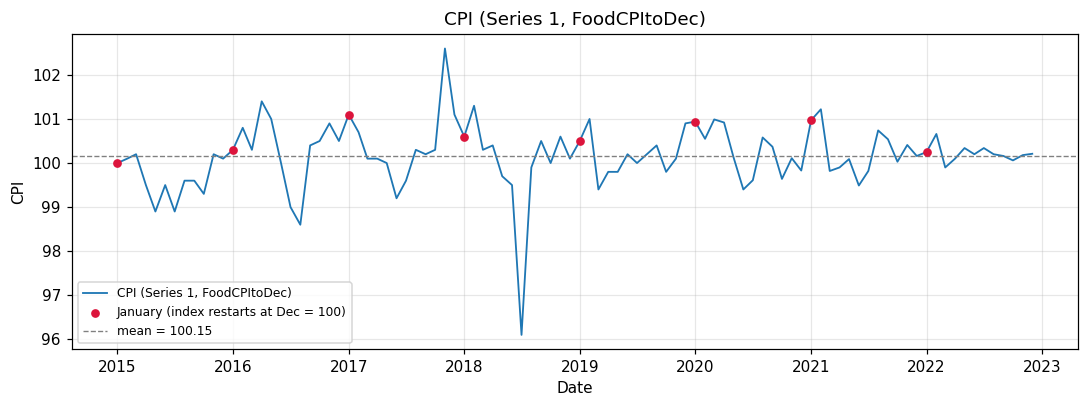

Observations beyond mean ± 3 sd: {'2017-11': 102.6, '2018-07': 96.1}
mean = 100.155, sd = 0.730, min = 96.100 (2018-07), max = 102.600 (2017-11)


In [7]:
plot_series("CPI", "p1_A1_cpi_plot.png")

**Comment on the result.** Series 1 fluctuates around a stable level (mean 100.15, sd 0.73, range 96.1–102.6) with no visible upward or downward drift over 2015–2022. The red dots show that the index **restarts every January** (it is measured against December of the previous year), so a stable level is partly a consequence of how the series is built, not only of the economy. Two observations lie beyond mean ± 3 sd: 2017-11 (102.6) and 2018-07 (96.1, the lowest value). The shape is irregular and mean-reverting, which suggests stationarity; this is tested formally in B and E.

**A2. CPI rate (Series 3) – Code / Result**

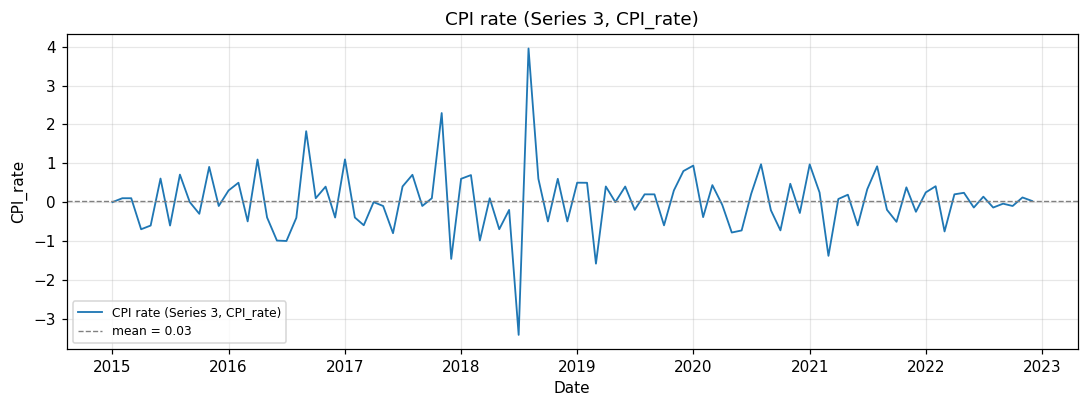

Observations beyond mean ± 3 sd: {'2018-07': -3.417, '2018-08': 3.954}
mean = 0.034, sd = 0.837, min = -3.417 (2018-07), max = 3.954 (2018-08)


In [8]:
plot_series("CPI_rate", "p1_A2_cpi_rate_plot.png")

**Comment on the result.** The monthly CPI rate moves around zero (mean 0.034 %, sd 0.84 %), mostly within ±1 percentage point. The two extreme points are 2018-07 (−3.42 %) and 2018-08 (+3.95 %): a sharp fall immediately followed by a rebound of the same size, the same event that produces the spike in Series 1. There is no trend and the variance looks roughly constant; a recurring month pattern (e.g. positive in January, negative in March) is checked in Section 1.7.

### B. Time series trend checking
Regression of the series on `Time`: $Y_t=\beta_0+\beta_1\,t+\varepsilon_t$. H0: β₁ = 0 (no linear trend); reject if p < 0.05, equivalently if the 95 % CI of β₁ excludes 0.

In [9]:
def trend_check(label):
    d = pd.DataFrame({"Y": SER[label].values, "Time": df1["Time"].values})
    lm = smf.ols("Y ~ Time", data=d).fit()
    ci = lm.conf_int().loc["Time"]
    exists = lm.pvalues["Time"] < ALPHA
    return {"series": label, "slope": lm.params["Time"], "std_err": lm.bse["Time"], "p_value": lm.pvalues["Time"],
            "ci_low": ci[0], "ci_high": ci[1], "R2": lm.rsquared,
            "conclusion": ("Trend exists (" + ("increasing" if lm.params["Time"] > 0 else "decreasing") + ")") if exists else "No significant linear trend"}

trend_tbl = pd.DataFrame([trend_check(k) for k in SER])
display(trend_tbl.round(5)); savecsv(trend_tbl, "p1_trend_check.csv")

,series,slope,std_err,p_value,ci_low,ci_high,R2,conclusion
0,CPI,0.00302,0.00269,0.26323,-0.00231,0.00835,0.01330,No significant linear trend
1,CPI_rate,-0.00029,0.00310,0.92567,-0.00644,0.00586,0.00009,No significant linear trend


**Comment on the result.** Both slopes are statistically zero: CPI slope = 0.0030 per month (p = 0.263, 95 % CI −0.0023 to 0.0084, R² = 0.013) and CPI rate slope = −0.0003 (p = 0.926, CI −0.0064 to 0.0059, R² ≈ 0). Since p > 0.05 and both CIs contain 0, H0 (no linear trend) is not rejected. Neither series has a deterministic linear trend over 2015–2022, consistent with the plots and with stationarity in level (no detrending needed).

### C. Autocorrelation function (ACF)
A lag is *significant* when the autocorrelation lies outside the 95 % Bartlett band. The ACF is used to read the maximum MA order **q**.

In [10]:
def acf_pacf_info(label):
    s = SER[label]
    a, aci = acf(s, nlags=NLAGS, alpha=ALPHA, fft=False)
    p, pci = pacf(s, nlags=NLAGS, alpha=ALPHA, method="ywm")
    half = lambda ci: (ci[:, 1] - ci[:, 0]) / 2
    sig_a = [l for l in range(1, NLAGS + 1) if abs(a[l]) > half(aci)[l]]
    sig_p = [l for l in range(1, NLAGS + 1) if abs(p[l]) > half(pci)[l]]
    return a, p, sig_a, sig_p

INFO = {k: acf_pacf_info(k) for k in SER}

def show_acf(label, fname):
    fig, ax = plt.subplots(figsize=(9, 3.6)); plot_acf(SER[label], lags=NLAGS, ax=ax, title=f"ACF – {NAME[label]}"); ax.set_xlabel("Lag (months)")
    savefig(fname)
    a, _, sig_a, _ = INFO[label]
    print("Significant ACF lags (1-%d):" % NLAGS, sig_a, "| values:", {l: round(a[l], 3) for l in sig_a})

**C1. CPI (Series 1)**

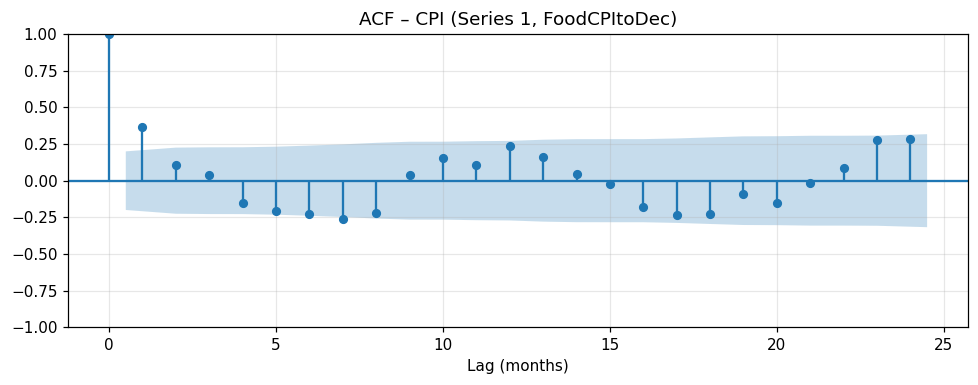

Significant ACF lags (1-24): [1, 7] | values: {1: np.float64(0.369), 7: np.float64(-0.259)}


In [11]:
show_acf("CPI", "p1_C1_cpi_acf.png")

**Comment on the result.** Only lag 1 (r = +0.37) and lag 7 (r = −0.26) lie outside the 95 % band; every other lag up to 24, including lag 12 (r = 0.24), is inside. The ACF therefore cuts off quickly instead of decaying slowly, which is the pattern of a stationary series. The lag-7 spike is isolated and has no obvious structural meaning. It sets an upper bound of q ≤ 7 before the cap of 3 is applied (Section 1.3).

**C2. CPI rate (Series 3)**

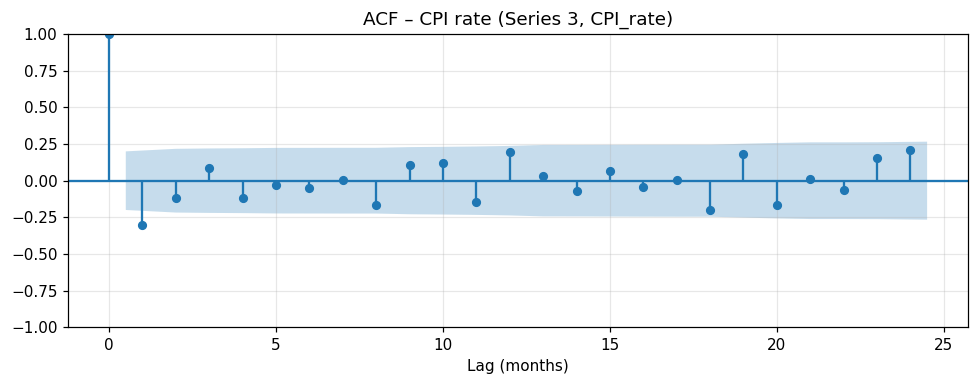

Significant ACF lags (1-24): [1] | values: {1: np.float64(-0.302)}


In [12]:
show_acf("CPI_rate", "p1_C2_cpi_rate_acf.png")

**Comment on the result.** Only lag 1 is significant (r = −0.30); all other lags are within the band. A single negative spike at lag 1 followed by no significant lags is the classical signature of an MA(1) component (typical for a series that behaves like a month-on-month difference). The maximum MA order read from the ACF is q = 1.

### D. Partial autocorrelation function (PACF)
Used to read the maximum AR order **p**.

In [13]:
def show_pacf(label, fname):
    fig, ax = plt.subplots(figsize=(9, 3.6)); plot_pacf(SER[label], lags=NLAGS, ax=ax, method="ywm", title=f"PACF – {NAME[label]}"); ax.set_xlabel("Lag (months)")
    savefig(fname)
    _, p, _, sig_p = INFO[label]
    print("Significant PACF lags (1-%d):" % NLAGS, sig_p, "| values:", {l: round(p[l], 3) for l in sig_p})

**D1. CPI (Series 1)**

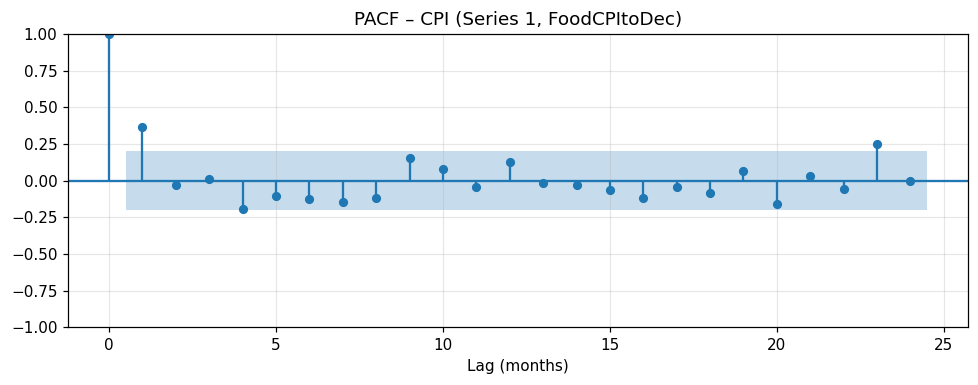

Significant PACF lags (1-24): [1, 23] | values: {1: np.float64(0.369), 23: np.float64(0.251)}


In [14]:
show_pacf("CPI", "p1_D1_cpi_pacf.png")

**Comment on the result.** Significant PACF values appear at lag 1 (0.37) and lag 23 (0.25). The sharp cut-off after lag 1 is the signature of an AR(1) process. Lag 23 is isolated, more than one seasonal cycle away, and is treated as chance/seasonal effect rather than an AR term. The PACF suggests p ≤ 1.

**D2. CPI rate (Series 3)**

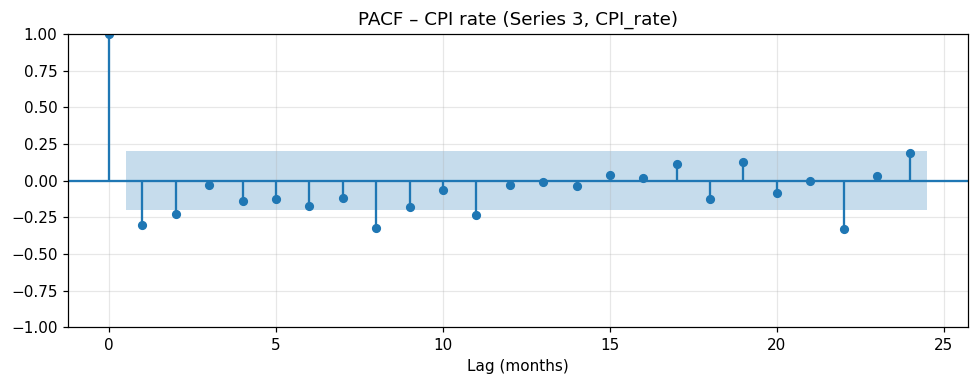

Significant PACF lags (1-24): [1, 2, 8, 11, 22] | values: {1: np.float64(-0.302), 2: np.float64(-0.228), 8: np.float64(-0.322), 11: np.float64(-0.234), 22: np.float64(-0.331)}


In [15]:
show_pacf("CPI_rate", "p1_D2_cpi_rate_pacf.png")

**Comment on the result.** Significant PACF lags are 1 (−0.30), 2 (−0.23), 8 (−0.32), 11 (−0.23) and 22 (−0.33), all negative and spread out instead of cutting off. A PACF that does not cut off, combined with the ACF cutting off at lag 1, points to an MA component (MA(1)), possibly mixed with a low-order AR term. Within the first 12 lags the largest significant lag is 11, so p is bounded by the cap of 3 in Section 1.3.

### E. Stationarity test
**ADF** (H0: unit root / non-stationary; reject if p ≤ 0.05) is the course test. **KPSS** (H0: stationary) is added as a cross-check: the two tests agree when ADF rejects and KPSS does not. If a series is not stationary it is differenced and retested; the number of differences is **d**.

In [16]:
def stationarity(label, max_d=2):
    s, rows = SER[label].copy(), []
    for d in range(max_d + 1):
        adf = adfuller(s.dropna(), regression="c", autolag="AIC")
        kp = kpss(s.dropna(), regression="c", nlags="auto")
        rows.append({"series": label, "differences": d, "ADF_stat": adf[0], "ADF_p": adf[1], "ADF_lags": adf[2],
                     "ADF_crit_5%": adf[4]["5%"], "KPSS_stat": kp[0], "KPSS_p(>=0.1 means 'large')": kp[1],
                     "ADF_says": "stationary" if adf[1] <= ALPHA else "non-stationary",
                     "KPSS_says": "stationary" if kp[1] > ALPHA else "non-stationary"})
        if adf[1] <= ALPHA:
            return d, pd.DataFrame(rows)
        s = s.diff().dropna()
    return max_d, pd.DataFrame(rows)

D, adf_rows = {}, []
for k in SER:
    D[k], t = stationarity(k); adf_rows.append(t)
stat_tbl = pd.concat(adf_rows, ignore_index=True)
display(stat_tbl.round(6)); savecsv(stat_tbl, "p1_stationarity.csv")
print("Selected d:", D)

,series,differences,ADF_stat,ADF_p,ADF_lags,ADF_crit_5%,KPSS_stat,KPSS_p(>=0.1 means 'large'),ADF_says,KPSS_says
0,CPI,0,-5.274952,0.000006,7,-2.894990,0.105363,0.1,stationary,stationary
1,CPI_rate,0,-5.986642,0.000000,10,-2.896195,0.106346,0.1,stationary,stationary


Selected d: {'CPI': 0, 'CPI_rate': 0}


**E1. CPI (Series 1) / E2. CPI rate (Series 3) – comment**

**Comment on the result.** ADF test (H0: unit root): CPI statistic = −5.27 (p = 6.2×10⁻⁶), CPI rate statistic = −5.99 (p ≈ 1.8×10⁻⁷), both far below the 5 % critical value (≈ −2.90) → H0 rejected, both series are stationary at level. The KPSS test (H0: stationary) gives statistics ≈ 0.105 with p ≥ 0.10 for both, so it does not reject stationarity: the two tests agree. No differencing is necessary: **d = 0** for CPI and for CPI rate.

## 1.3 Determine parameters p, q and d in ARIMA(p, d, q)
* **p<sub>max</sub>** = largest significant PACF lag among lags ≤ `LAG_WINDOW` (12), bounded by `ORDER_CAP` (3).
* **q<sub>max</sub>** = largest significant ACF lag among lags ≤ `LAG_WINDOW` (12), bounded by `ORDER_CAP` (3).
* **d** = number of differences needed for the ADF test to accept stationarity.

Lags beyond 12 are not used for the order: with n = 96 they are one or more full seasonal cycles away and an isolated spike there (e.g. lag 22–24) is much more likely a seasonal / chance effect than an AR/MA term; seasonal effects are modelled explicitly in Section 1.7.

In [17]:
def max_order(sig_lags):
    inwin = [l for l in sig_lags if l <= LAG_WINDOW]
    raw = max(inwin) if inwin else 1            # at least 1 so that a grid exists
    return min(raw, ORDER_CAP), raw

PQ = {}
rows = []
for k in SER:
    _, _, sa, sp = INFO[k]
    pmax, praw = max_order(sp); qmax, qraw = max_order(sa)
    PQ[k] = (pmax, qmax)
    rows.append({"series": k, "sig_PACF_lags": sp, "p_max_raw(<=12)": praw, "p_max": pmax,
                 "sig_ACF_lags": sa, "q_max_raw(<=12)": qraw, "q_max": qmax, "d": D[k]})
order_tbl = pd.DataFrame(rows); display(order_tbl)
savecsv(order_tbl.astype(str), "p1_order_limits.csv")

,series,sig_PACF_lags,p_max_raw(<=12),p_max,sig_ACF_lags,q_max_raw(<=12),q_max,d
0,CPI,"[1, 23]",1,1,"[1, 7]",7,3,0
1,CPI_rate,"[1, 2, 8, 11, 22]",11,3,[1],1,1,0


**A1 / A2 – maximum p (PACF)**

**Comment on the result.** **A1 – CPI:** significant PACF lags {1, 23}; the largest lag ≤ 12 is 1 → **p_max = 1**. **A2 – CPI rate:** significant lags {1, 2, 8, 11, 22}; the largest lag ≤ 12 is 11, bounded by the cap → **p_max = 3**. *(Insert the slide reference for "p from PACF" and for the cap of 3.)*

**B1 / B2 – maximum q (ACF)**

**Comment on the result.** **B1 – CPI:** significant ACF lags {1, 7}; 7 is bounded by the cap → **q_max = 3**. **B2 – CPI rate:** only lag 1 is significant → **q_max = 1**. *(Insert the slide reference for "q from ACF".)*

**C1 / C2 – value of d (stationarity test)**

**Comment on the result.** **C1 – CPI:** ADF rejects the unit root at level (p = 6.2×10⁻⁶) → **d = 0**. **C2 – CPI rate:** ADF rejects the unit root at level (p ≈ 1.8×10⁻⁷) → **d = 0**.

### Deterministic term (constant)
`ARIMA(trend='c')` estimates a constant (= the process mean for d = 0). It is kept only if the series mean differs significantly from 0 (one-sample t-test); otherwise `trend='n'` is used. This also fixes the model used in Sections 1.4–1.7 so that ARIMA and SARIMA are directly comparable.

In [18]:
TREND, rows = {}, []
for k in SER:
    t, p = stats.ttest_1samp(SER[k], 0.0)
    TREND[k] = "c" if (p < ALPHA and D[k] == 0) else "n"
    rows.append({"series": k, "mean": SER[k].mean(), "t_stat(mean=0)": t, "p_value": p, "trend_used": TREND[k]})
display(pd.DataFrame(rows).round(4)); print(TREND)

,series,mean,t_stat(mean=0),p_value,trend_used
0,CPI,100.1548,1343.9864,0.0000,c
1,CPI_rate,0.0335,0.3928,0.6954,n


{'CPI': 'c', 'CPI_rate': 'n'}


## 1.4 Estimating ARIMA models and model selection
For every (p, q) with 0 ≤ p ≤ p<sub>max</sub>, 0 ≤ q ≤ q<sub>max</sub> (except the empty model) and the d found above, ARIMA(p, d, q) is estimated by maximum likelihood. For each model we keep AIC, BIC, the 95 % CI of every coefficient, a *stable* flag (all CIs exclude 0) and a *converged* flag.

**Selection rule:** among converged models with stable coefficients take the lowest AIC. If no such model exists the lowest-AIC converged model is reported and flagged.

In [19]:
def fit_arima(s, order, trend):
    res = ARIMA(s, order=order, trend=trend if order[1] == 0 else "n").fit()
    ret = getattr(res, "mle_retvals", None) or {}
    return res, bool(ret.get("converged", True))

def ci_check(res):
    ci = res.conf_int()
    params = [n for n in res.param_names if n != "sigma2"]
    bad = [n for n in params if ci.loc[n].iloc[0] <= 0 <= ci.loc[n].iloc[1]]
    return len(bad) == 0, bad

def arima_grid(label):
    s, (pmax, qmax), d, tr = SER[label], PQ[label], D[label], TREND[label]
    rows, fits, ci_rows = [], {}, []
    for p, q in itertools.product(range(pmax + 1), range(qmax + 1)):
        if p == q == 0: continue
        res, conv = fit_arima(s, (p, d, q), tr)
        stable, bad = ci_check(res)
        rows.append({"series": label, "order": (p, d, q), "AIC": res.aic, "BIC": res.bic, "stable": stable,
                     "unstable_params": ", ".join(bad) or "-", "converged": conv})
        fits[(p, d, q)] = res
        ci = res.conf_int()
        for n in res.param_names:
            ci_rows.append({"series": label, "order": str((p, d, q)), "param": n, "coef": res.params[n],
                            "ci_low": ci.loc[n].iloc[0], "ci_high": ci.loc[n].iloc[1], "excludes_0": n not in bad if n != "sigma2" else np.nan})
    return pd.DataFrame(rows), fits, pd.DataFrame(ci_rows)

def select_best(tbl):
    ok = tbl[tbl["converged"] & tbl["stable"]]
    flag = "OK (stable, lowest AIC)"
    if ok.empty:
        ok, flag = tbl[tbl["converged"]], "FALLBACK: no stable model - lowest AIC"
    best = ok.loc[ok["AIC"].idxmin()]
    return best, flag

GRID, FITS, CIS, BEST = {}, {}, [], {}
for k in SER:
    GRID[k], FITS[k], ci_t = arima_grid(k); CIS.append(ci_t)
savecsv(pd.concat(CIS), "p1_arima_all_coefficient_CIs.csv")
savecsv(pd.concat(GRID.values()).astype({"order": str}), "p1_arima_grid.csv")

**A1. CPI (Series 1) – estimation of all candidate models**

In [20]:
t = GRID["CPI"].copy(); t["order"] = t["order"].astype(str); display(t.round(3).reset_index(drop=True))

,series,order,AIC,BIC,stable,unstable_params,converged
0,CPI,"(0, 0, 1)",203.583,211.276,True,-,True
1,CPI,"(0, 0, 2)",205.314,215.571,False,ma.L2,True
2,CPI,"(0, 0, 3)",205.567,218.389,False,"ma.L2, ma.L3",True
3,CPI,"(1, 0, 0)",203.112,210.805,True,-,True
4,CPI,"(1, 0, 1)",205.008,215.265,False,"ar.L1, ma.L1",True
5,CPI,"(1, 0, 2)",203.973,216.794,False,"ma.L1, ma.L2",True
6,CPI,"(1, 0, 3)",205.006,220.392,False,"ma.L1, ma.L2, ma.L3",True


**A2. CPI (Series 1) – best ARIMA model**

In [21]:
BEST["CPI"] = select_best(GRID["CPI"]); b, flag = BEST["CPI"]
print(f"Best ARIMA for CPI: {b['order']}   AIC = {b['AIC']:.3f}   status: {flag}")
print(FITS["CPI"][b["order"]].summary().tables[1])

Best ARIMA for CPI: (1, 0, 0)   AIC = 203.112   status: OK (stable, lowest AIC)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        100.1542      0.123    811.072      0.000      99.912     100.396
ar.L1          0.3656      0.080      4.562      0.000       0.209       0.523
sigma2         0.4556      0.030     15.269      0.000       0.397       0.514


**Comment on the result.** Seven ARIMA(p, 0, q) models were estimated with a constant (the series mean is 100.15, p < 0.001). Only ARIMA(0,0,1) (AIC 203.58) and ARIMA(1,0,0) (AIC 203.11) have all coefficients significantly different from 0; in every other candidate at least one AR/MA coefficient has a CI containing 0 (column *unstable_params*). Among the stable models the lowest AIC is **ARIMA(1,0,0)**: φ = 0.366 (95 % CI 0.209–0.523), constant 100.154. The two stable models differ by only 0.47 AIC points, so they are practically equivalent; the rule selects AR(1), which also agrees with the PACF. The Ljung–Box test on the residuals gives p = 0.073 (lag 12) and p = 0.008 (lag 24): some autocorrelation remains at longer lags, which motivates the seasonal model of Section 1.7.

**B1. CPI rate (Series 3) – estimation of all candidate models**

In [22]:
t = GRID["CPI_rate"].copy(); t["order"] = t["order"].astype(str); display(t.round(3).reset_index(drop=True))

,series,order,AIC,BIC,stable,unstable_params,converged
0,CPI_rate,"(0, 0, 1)",227.413,232.542,True,-,True
1,CPI_rate,"(1, 0, 0)",232.426,237.555,True,-,True
2,CPI_rate,"(1, 0, 1)",222.827,230.521,True,-,True
3,CPI_rate,"(2, 0, 0)",229.552,237.245,True,-,True
4,CPI_rate,"(2, 0, 1)",224.794,235.052,False,ar.L2,True
5,CPI_rate,"(3, 0, 0)",231.495,241.753,False,ar.L3,True
6,CPI_rate,"(3, 0, 1)",226.727,239.549,False,"ar.L2, ar.L3",True


**B2. CPI rate (Series 3) – best ARIMA model**

In [23]:
BEST["CPI_rate"] = select_best(GRID["CPI_rate"]); b, flag = BEST["CPI_rate"]
print(f"Best ARIMA for CPI rate: {b['order']}   AIC = {b['AIC']:.3f}   status: {flag}")
print(FITS["CPI_rate"][b["order"]].summary().tables[1])

Best ARIMA for CPI rate: (1, 0, 1)   AIC = 222.827   status: OK (stable, lowest AIC)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3902      0.081      4.795      0.000       0.231       0.550
ma.L1         -0.8421      0.077    -10.871      0.000      -0.994      -0.690
sigma2         0.5568      0.046     12.095      0.000       0.467       0.647


**Comment on the result.** Series 3 has mean 0.034 (t-test p = 0.70), so no constant is estimated. Seven candidates were fitted; ARIMA(0,0,1), (1,0,0), (1,0,1) and (2,0,0) have all coefficients significant, while (2,0,1), (3,0,0) and (3,0,1) contain an insignificant AR term. The lowest AIC among the stable models is **ARIMA(1,0,1)** with AIC = 222.83: φ = 0.390 (CI 0.231–0.550) and θ = −0.842 (CI −0.994 to −0.690), clearly better than the next stable model (AIC 227.41 for MA(1)). The Ljung–Box test shows remaining autocorrelation (p = 0.036 at lag 12, p = 0.001 at lag 24), again pointing to seasonal structure.

**Residual diagnostics of the two selected models (supporting check).** If the model captured the autocorrelation, the Ljung–Box test should not reject "no residual autocorrelation" (p > 0.05).

In [24]:
rows = []
for k in SER:
    order = BEST[k][0]["order"]; res = FITS[k][order]
    lb = acorr_ljungbox(res.resid, lags=[12, 24], model_df=order[0] + order[2], return_df=True)
    rows.append({"series": k, "order": str(order), "LB_p(lag12)": lb["lb_pvalue"].iloc[0], "LB_p(lag24)": lb["lb_pvalue"].iloc[1],
                 "resid_mean": res.resid.mean(), "resid_sd": res.resid.std()})
diag = pd.DataFrame(rows); display(diag.round(4)); savecsv(diag, "p1_ljung_box.csv")

,series,order,LB_p(lag12),LB_p(lag24),resid_mean,resid_sd
0,CPI,"(1, 0, 0)",0.0734,0.0076,0.0006,0.6786
1,CPI_rate,"(1, 0, 1)",0.0361,0.0010,0.1305,0.7390


In [25]:
OPT = {k: BEST[k][0]["order"] for k in SER}
print("Optimal ARIMA orders (pO, dO, qO):", OPT, "| constant:", TREND)

Optimal ARIMA orders (pO, dO, qO): {'CPI': (1, 0, 0), 'CPI_rate': (1, 0, 1)} | constant: {'CPI': 'c', 'CPI_rate': 'n'}


## 1.5 Mean values forecasting for ARIMA model
The optimal model is re-estimated on the whole sample and used to forecast the next 12 months (Jan–Dec 2023). The table gives the forecast mean and its 95 % interval.

In [26]:
FC = {}
def mean_forecast(label, fname):
    s, order = SER[label], OPT[label]
    res, _ = fit_arima(s, order, TREND[label])
    fc = res.get_forecast(steps=FORECAST_STEPS).summary_frame(alpha=ALPHA)
    FC[label] = fc
    hist = s.iloc[-48:]
    fig, ax = plt.subplots(figsize=(10, 3.8))
    ax.plot(hist.index, hist.values, label="Observed (last 48 months)")
    ax.plot(fc.index, fc["mean"], "k--", marker="o", ms=3, label="Forecast mean")
    ax.fill_between(fc.index, fc["mean_ci_lower"], fc["mean_ci_upper"], color="k", alpha=.12, label="95% interval")
    ax.set_title(f"Mean forecast – {NAME[label]} – ARIMA{order}"); ax.set_xlabel("Date"); ax.legend(fontsize=8)
    savefig(fname)
    out = fc[["mean", "mean_ci_lower", "mean_ci_upper"]].copy(); out.index = out.index.strftime("%Y-%m")
    display(out.round(3)); savecsv(out, f"p1_forecast_{label}.csv", index=True)

**CPI (Series 1) – Code / Result**

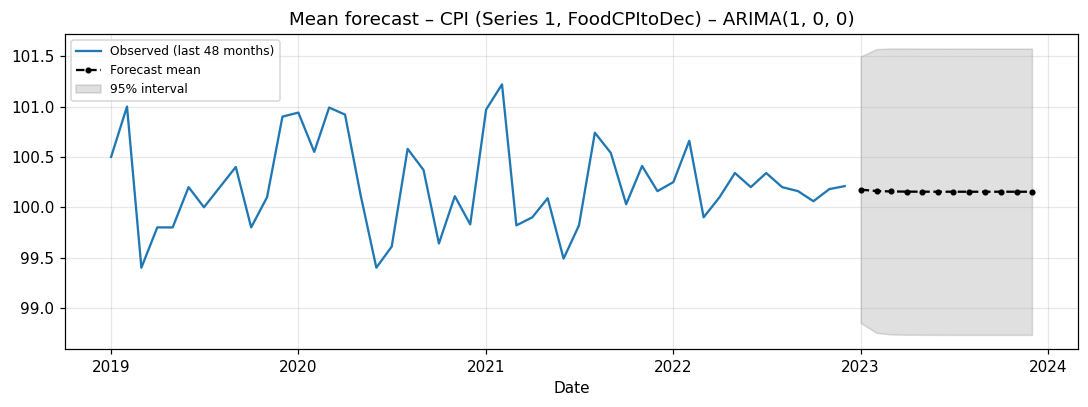

FoodCPItoDec,mean,mean_ci_lower,mean_ci_upper
2023-01,100.175,98.852,101.498
2023-02,100.162,98.753,101.570
2023-03,100.157,98.737,101.577
2023-04,100.155,98.734,101.576
2023-05,100.155,98.733,101.576
2023-06,100.154,98.733,101.576
2023-07,100.154,98.733,101.576
2023-08,100.154,98.733,101.576
2023-09,100.154,98.733,101.576
2023-10,100.154,98.733,101.576


In [27]:
mean_forecast("CPI", "p1_15_cpi_forecast.png")

**Comment on the result.** The forecast mean starts at 100.18 in January 2023 and converges to the sample mean (100.15) within about three months; the 95 % interval stays at about 98.7–101.6. This is the expected behaviour of a stationary ARIMA(1,0,0) with φ = 0.37: the memory of the process is short, so beyond the first month the model can only predict the mean. The forecast is informative about the level and the uncertainty (± 1.4 index points), not about month-to-month movements.

**CPI rate (Series 3) – Code / Result**

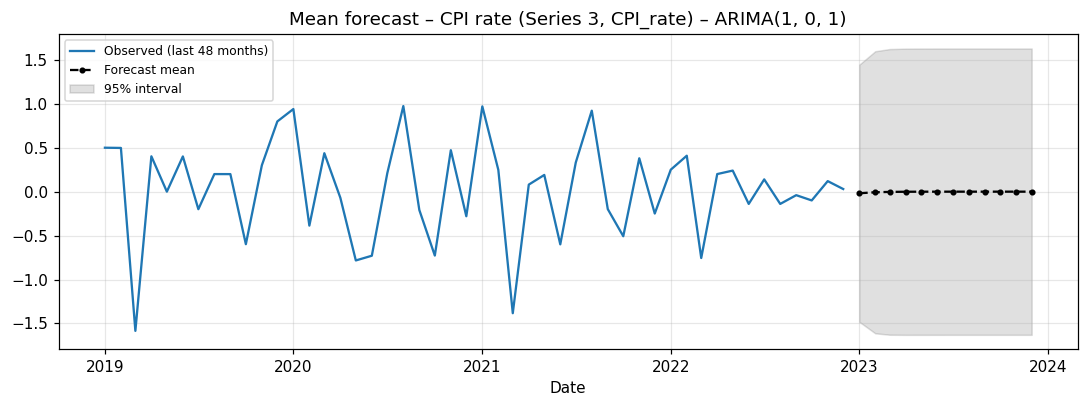

CPI_rate,mean,mean_ci_lower,mean_ci_upper
2023-01,-0.018,-1.481,1.444
2023-02,-0.007,-1.612,1.598
2023-03,-0.003,-1.628,1.623
2023-04,-0.001,-1.630,1.627
2023-05,-0.000,-1.629,1.629
2023-06,-0.000,-1.629,1.629
2023-07,-0.000,-1.629,1.629
2023-08,-0.000,-1.629,1.629
2023-09,-0.000,-1.629,1.629
2023-10,-0.000,-1.629,1.629


In [28]:
mean_forecast("CPI_rate", "p1_15_cpi_rate_forecast.png")

**Comment on the result.** The forecast of the monthly CPI rate is −0.02 % in January 2023 and then essentially 0 %, with a constant 95 % interval of about ±1.63 percentage points. With no constant and a short-memory ARMA(1,1), the model predicts "no change" and its uncertainty is dominated by the noise level (σ² = 0.56). Individual future months, e.g. seasonal highs and lows, cannot be predicted by this non-seasonal model.

## 1.6 Machine learning in ARIMA model forecasting
The series is split **chronologically** (first 80 % = train, last 20 % = test; never shuffled). The model is estimated on the train part only and forecasts the whole test period (multi-step, no re-fitting). Accuracy is measured with RMSE (and MAE), and compared with two naive benchmarks: *train mean* and *last observed value*.

In [29]:
def split(label):
    s = SER[label]; n_tr = int(len(s) * (1 - TEST_FRAC))
    return s.iloc[:n_tr], s.iloc[n_tr:]

rmse = lambda y, f: float(np.sqrt(mean_squared_error(y, f)))

def baselines(train, test):
    return {"naive_train_mean": rmse(test, np.full(len(test), train.mean())),
            "naive_last_value": rmse(test, np.full(len(test), train.iloc[-1]))}

def show_split(label):
    tr, te = split(label)
    print(f"[{label}] train: {tr.index[0]:%Y-%m} -> {tr.index[-1]:%Y-%m} (n={len(tr)}) | test: {te.index[0]:%Y-%m} -> {te.index[-1]:%Y-%m} (n={len(te)})")

**A1. CPI (Series 1) – train / test split**

In [30]:
show_split("CPI")

[CPI] train: 2015-01 -> 2021-04 (n=76) | test: 2021-05 -> 2022-12 (n=20)


**A2. CPI (Series 1) – forecast with the optimal (pO, dO, qO)**

In [31]:
ARIMA_TT = {}
def arima_train_test(label, fname):
    tr, te = split(label); order = OPT[label]
    res, conv = fit_arima(tr, order, TREND[label])
    pred = res.get_forecast(steps=len(te)).predicted_mean; pred.index = te.index
    r = {"series": label, "order": str(order), "train_n": len(tr), "test_n": len(te), "RMSE": rmse(te, pred),
         "MAE": float(mean_absolute_error(te, pred)), "converged": conv, **baselines(tr, te)}
    ARIMA_TT[label] = r
    fig, ax = plt.subplots(figsize=(10, 3.8))
    ax.plot(tr.index, tr.values, color="black", lw=1, label="Train"); ax.plot(te.index, te.values, color="orange", label="Test (actual)")
    ax.plot(te.index, pred.values, color="red", label=f"ARIMA{order} forecast")
    ax.set_title(f"Train/test ARIMA{order} – {NAME[label]} – RMSE = {r['RMSE']:.4f}"); ax.legend(fontsize=8)
    savefig(fname); display(pd.DataFrame([r]).round(4))

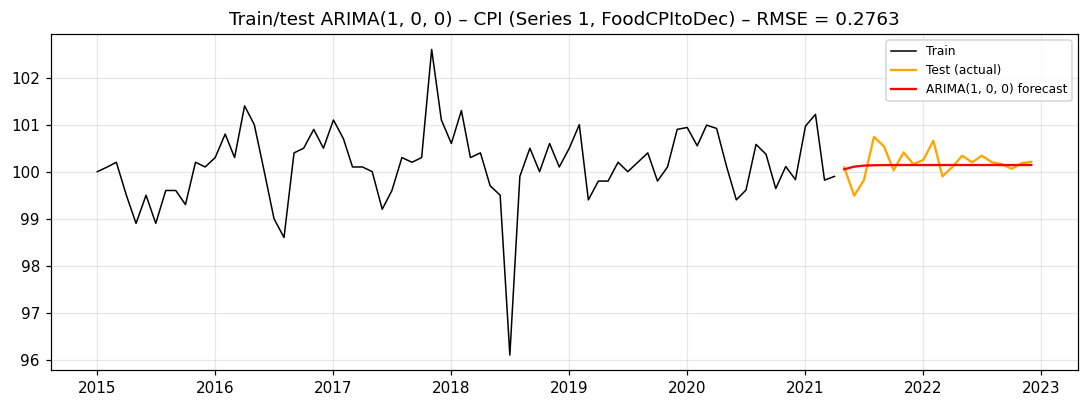

,series,order,train_n,test_n,RMSE,MAE,converged,naive_train_mean,naive_last_value
0,CPI,"(1, 0, 0)",76,20,0.2763,0.1999,True,0.2798,0.4028


In [32]:
arima_train_test("CPI", "p1_16_cpi_arima_tt.png")

**B1. CPI rate (Series 3) – train / test split**

In [33]:
show_split("CPI_rate")

[CPI_rate] train: 2015-01 -> 2021-04 (n=76) | test: 2021-05 -> 2022-12 (n=20)


**B2. CPI rate (Series 3) – forecast with the optimal (pO, dO, qO)**

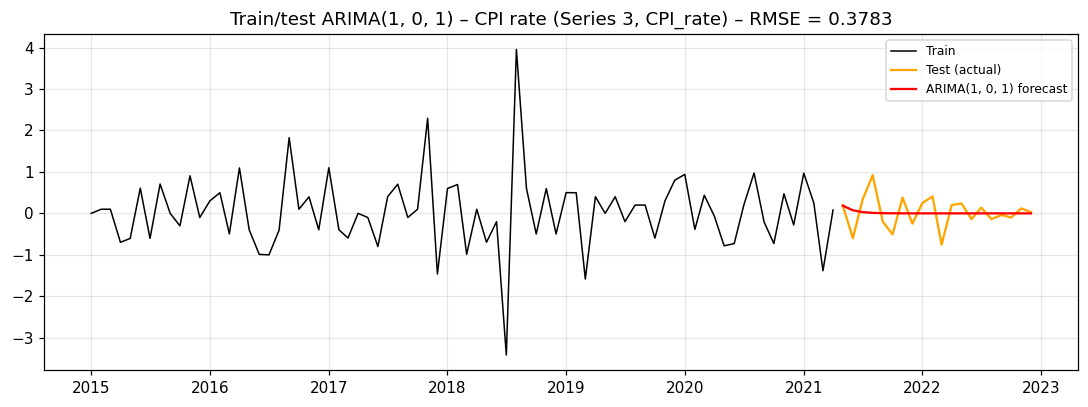

,series,order,train_n,test_n,RMSE,MAE,converged,naive_train_mean,naive_last_value
0,CPI_rate,"(1, 0, 1)",76,20,0.3783,0.2896,True,0.3763,0.3802


In [34]:
arima_train_test("CPI_rate", "p1_16_cpi_rate_arima_tt.png")

**Comment on the result.** On the 20 test months (2021-05 to 2022-12) ARIMA(1,0,0) reaches RMSE = 0.2763 (MAE 0.200) for CPI, and ARIMA(1,0,1) reaches RMSE = 0.3783 (MAE 0.290) for CPI rate. Compared with naive benchmarks: for CPI the train-mean forecast gives 0.2798 and the last value 0.4028, so ARIMA is only about 1 % better than the mean and 31 % better than the last value; for CPI rate the train mean gives 0.3763 and the last value 0.3802, so ARIMA is **not better than a constant forecast**. The test series is short and nearly random around its mean, so a non-seasonal ARIMA adds little out-of-sample information. These RMSE values are the baseline for the SARIMA models.

**Optional step of the template – iterate over several (p, d, q) and keep the lowest RMSE.** All grid orders of Section 1.4 are re-fitted on the train part. *Note:* choosing the order by test RMSE uses the test data for selection, so its RMSE is optimistic; it is shown for comparison with the AIC-based choice.

In [35]:
rows = []
for k in SER:
    tr, te = split(k)
    for order in FITS[k]:
        res, conv = fit_arima(tr, order, TREND[k])
        pr = res.get_forecast(steps=len(te)).predicted_mean
        g = GRID[k].set_index(GRID[k]["order"].astype(str)).loc[str(order)]
        rows.append({"series": k, "order": str(order), "RMSE_test": rmse(te, pr), "converged": conv,
                     "full-sample AIC": g["AIC"], "stable (full sample)": g["stable"]})
loop_tbl = pd.DataFrame(rows).sort_values(["series", "RMSE_test"]).reset_index(drop=True)
display(loop_tbl.round(4)); savecsv(loop_tbl, "p1_arima_rmse_loop.csv")

,series,order,RMSE_test,converged,full-sample AIC,stable (full sample)
0,CPI,"(0, 0, 3)",0.2667,True,205.5668,False
1,CPI,"(1, 0, 3)",0.2680,True,205.0061,False
2,CPI,"(1, 0, 0)",0.2763,True,203.1121,True
3,CPI,"(1, 0, 1)",0.2770,True,205.0078,False
4,CPI,"(0, 0, 2)",0.2795,True,205.3141,False
5,CPI,"(0, 0, 1)",0.2798,True,203.5833,True
6,CPI,"(1, 0, 2)",0.2819,True,203.9726,False
7,CPI_rate,"(2, 0, 0)",0.3636,True,229.5518,True
8,CPI_rate,"(3, 0, 0)",0.3697,True,231.4953,False
9,CPI_rate,"(0, 0, 1)",0.3745,True,227.4134,True


**Comment on the result.** Re-fitting all grid orders on the train part gives RMSE between 0.267 and 0.282 for CPI and between 0.364 and 0.378 for CPI rate. For CPI the lowest RMSE comes from (0,0,3) (0.267), which is not stable on the full sample; for CPI rate it comes from (2,0,0) (0.364), which is stable but has a clearly higher AIC (229.6 vs 222.8). The differences are small compared with the noise of a 20-point test set. The order selected by AIC and stability in 1.4 is therefore kept; picking the best RMSE here would be selection on the test data and optimistic.

## 1.7 Machine learning in SARIMA model forecasting
SARIMA(p<sub>O</sub>, d<sub>O</sub>, q<sub>O</sub>)(P, D, Q, m) with the non-seasonal part fixed to the optimal ARIMA order, **D = 0, m = 12**, same constant specification and same train/test split as Section 1.6.

**Supporting evidence that a seasonal term with m = 12 makes sense:** one-way ANOVA (and the non-parametric Kruskal–Wallis test) of the series on calendar month.

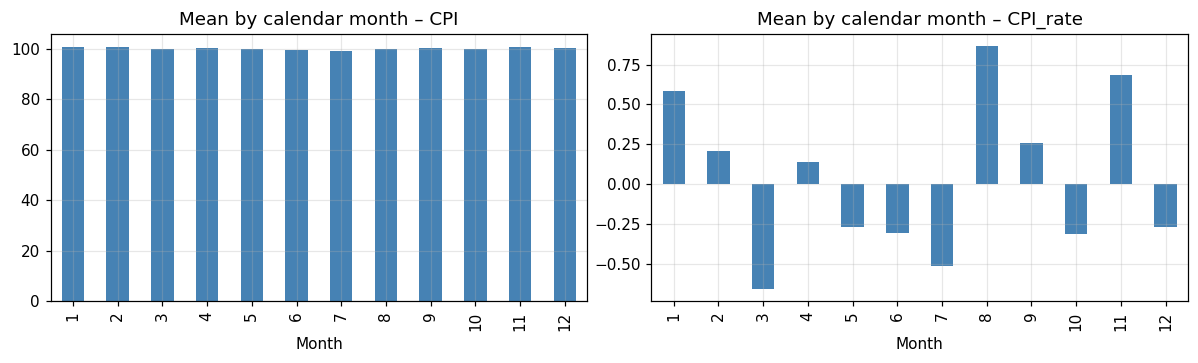

,series,ANOVA_F,ANOVA_p,Kruskal_H,Kruskal_p,ACF_lag12,month with highest mean,month with lowest mean
0,CPI,3.9633,0.0001,36.7674,0.0001,0.2354,2,7
1,CPI_rate,3.6906,0.0003,38.3300,0.0001,0.1981,8,3


In [36]:
rows = []
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, k in zip(axes, SER):
    groups = [g.values for _, g in SER[k].groupby(SER[k].index.month)]
    f, p_a = stats.f_oneway(*groups); h, p_k = stats.kruskal(*groups)
    rows.append({"series": k, "ANOVA_F": f, "ANOVA_p": p_a, "Kruskal_H": h, "Kruskal_p": p_k,
                 "ACF_lag12": INFO[k][0][12], "month with highest mean": int(SER[k].groupby(SER[k].index.month).mean().idxmax()),
                 "month with lowest mean": int(SER[k].groupby(SER[k].index.month).mean().idxmin())})
    SER[k].groupby(SER[k].index.month).mean().plot.bar(ax=ax, color="steelblue"); ax.set_title(f"Mean by calendar month – {k}"); ax.set_xlabel("Month")
savefig("p1_17_monthly_means.png")
seas_tbl = pd.DataFrame(rows); display(seas_tbl.round(4)); savecsv(seas_tbl, "p1_seasonality_tests.csv")

In [37]:
SARIMA_ALL, SARIMA_BEST = {}, {}

def fit_sarima(train, order, seas, trend):
    res = SARIMAX(train, order=order, seasonal_order=seas, trend=trend).fit(disp=False, maxiter=500)   # enforce_* = True (default)
    return res, bool(res.mle_retvals.get("converged", False))

def sarima_one(label, P, Q, plot_name=None):
    tr, te = split(label); order, seas = OPT[label], (P, D_SEAS, Q, M_SEAS)
    res, conv = fit_sarima(tr, order, seas, TREND[label])
    pr = res.get_forecast(steps=len(te)).predicted_mean; pr.index = te.index
    roots = np.r_[res.arroots, res.maroots]; min_root = float(np.min(np.abs(roots))) if len(roots) else np.inf
    e = rmse(te, pr)
    # a fit is "valid" if it converged, has AR/MA roots clearly outside the unit circle and does not forecast absurdly
    valid = bool(conv and min_root > 1.01 and np.isfinite(e) and e < 3 * ARIMA_TT[label]["naive_train_mean"])
    r = {"series": label, "order": str(order), "seasonal_order": str(seas), "RMSE": e, "AIC_train": res.aic,
         "converged": conv, "min_|root|": min_root, "valid": valid}
    if plot_name:
        fig, ax = plt.subplots(figsize=(10, 3.8))
        ax.plot(tr.index, tr.values, color="black", lw=1, label="Train"); ax.plot(te.index, te.values, color="orange", label="Test (actual)")
        ax.plot(te.index, pr.values, color="blue", label=f"SARIMA{order}{seas}")
        ax.set_title(f"SARIMA{order}{seas} – {NAME[label]} – RMSE = {r['RMSE']:.4f}"); ax.legend(fontsize=8)
        savefig(plot_name)
    return r, pr

def sarima_grid(label, fname):
    rows = [sarima_one(label, P, Q)[0] for P, Q in itertools.product(P_RANGE, Q_RANGE) if not (P == 0 and Q == 0)]
    t = pd.DataFrame(rows)
    ok = t[t["valid"]]
    best = (ok if not ok.empty else t[t["converged"]]).sort_values("RMSE").iloc[0]
    P, Q = eval(best["seasonal_order"])[0], eval(best["seasonal_order"])[2]
    _, pr = sarima_one(label, P, Q, fname)
    t["ARIMA_RMSE"] = ARIMA_TT[label]["RMSE"]; t["improvement_vs_ARIMA_%"] = 100 * (1 - t["RMSE"] / t["ARIMA_RMSE"])
    SARIMA_ALL[label] = t; SARIMA_BEST[label] = best
    display(t.sort_values("RMSE").round(4).reset_index(drop=True))
    print(f"-> Best valid SARIMA by test RMSE: {best['order']}{best['seasonal_order']}  RMSE = {best['RMSE']:.4f}"
          f"  (ARIMA: {ARIMA_TT[label]['RMSE']:.4f}; naive train mean: {ARIMA_TT[label]['naive_train_mean']:.4f})")

**A1. CPI (Series 1) – one combination (P, D, Q, m) = (1, 0, 1, 12)**

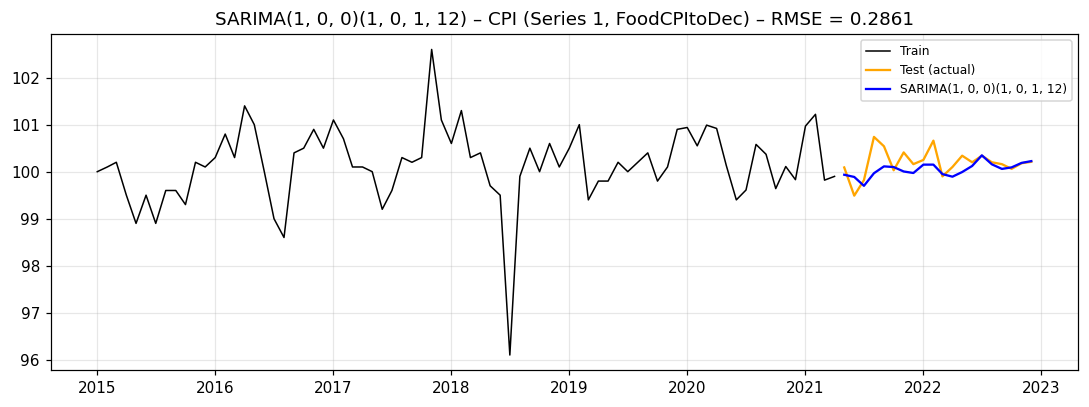

,series,order,seasonal_order,RMSE,AIC_train,converged,min_|root|,valid
0,CPI,"(1, 0, 0)","(1, 0, 1, 12)",0.2861,189.6302,True,1.0003,False


In [38]:
r, _ = sarima_one("CPI", 1, 1, "p1_17_cpi_sarima_example.png"); display(pd.DataFrame([r]).round(4))

**A2. CPI (Series 1) – grid over P, Q (D = 0, m = 12); lowest RMSE among valid fits = best model**

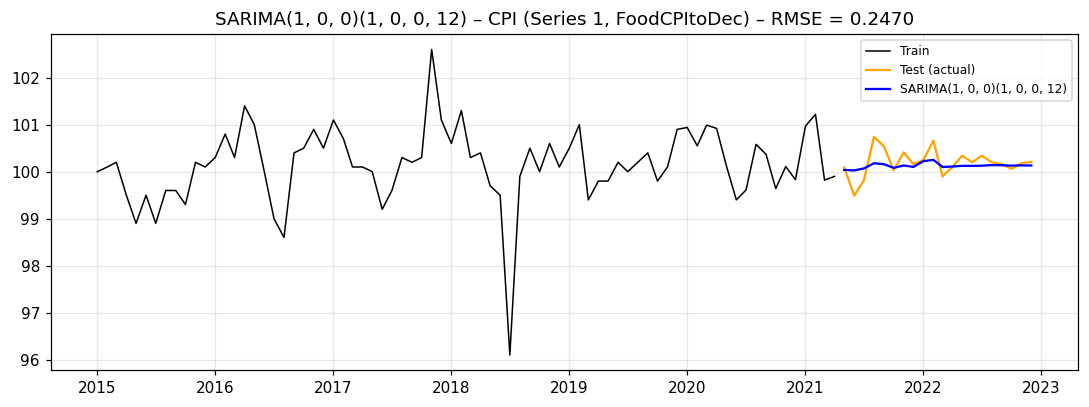

,series,order,seasonal_order,RMSE,AIC_train,converged,min_|root|,valid,ARIMA_RMSE,improvement_vs_ARIMA_%
0,CPI,"(1, 0, 0)","(1, 0, 0, 12)",2.470000e-01,177.5343,True,1.2047,True,0.2763,1.063160e+01
1,CPI,"(1, 0, 0)","(2, 0, 0, 12)",2.746000e-01,177.2233,True,1.0777,True,0.2763,6.097000e-01
2,CPI,"(1, 0, 0)","(1, 0, 1, 12)",2.861000e-01,189.6302,True,1.0003,False,0.2763,-3.536600e+00
3,CPI,"(1, 0, 0)","(2, 0, 2, 12)",2.883000e-01,179.5637,True,1.0824,True,0.2763,-4.335100e+00
4,CPI,"(1, 0, 0)","(1, 0, 2, 12)",2.926000e-01,177.1718,True,1.0586,True,0.2763,-5.871200e+00
5,CPI,"(1, 0, 0)","(0, 0, 2, 12)",2.975000e-01,175.8685,True,1.0617,True,0.2763,-7.653100e+00
6,CPI,"(1, 0, 0)","(0, 0, 1, 12)",1.442500e+00,272.9382,True,1.0024,False,0.2763,-4.220071e+02
7,CPI,"(1, 0, 0)","(2, 0, 1, 12)",1.415861e+08,128.7548,True,1.0000,False,0.2763,-5.123769e+10


-> Best valid SARIMA by test RMSE: (1, 0, 0)(1, 0, 0, 12)  RMSE = 0.2470  (ARIMA: 0.2763; naive train mean: 0.2798)


In [39]:
sarima_grid("CPI", "p1_17_cpi_sarima_best.png")

**Comment on the result.** Seasonality exists: the ANOVA of CPI on calendar month is significant (F = 3.96, p = 0.0001; Kruskal–Wallis p = 0.0001), so m = 12 is justified. Of the 8 seasonal combinations, 3 are rejected as invalid (AR/MA root on the unit circle, or absurd forecasts: (0,0,1,12) RMSE 1.44, (2,0,1,12) RMSE 1.4×10⁸, (1,0,1,12) root ≈ 1.0003). Among the valid ones the lowest RMSE is **SARIMA(1,0,0)(1,0,0,12)** with RMSE = 0.2470, which is 10.6 % better than ARIMA(1,0,0) (0.2763) and than the train-mean benchmark (0.2798). The example in A1, (1,0,1,12), is worse than ARIMA (0.2861), and the other valid fits are at best marginally better (+0.6 %) or worse than ARIMA, so the gain is not systematic. Because the best of 8 candidates is chosen on only 20 test points, the improvement is probably optimistic.

**B1. CPI rate (Series 3) – one combination (P, D, Q, m) = (1, 0, 1, 12)**

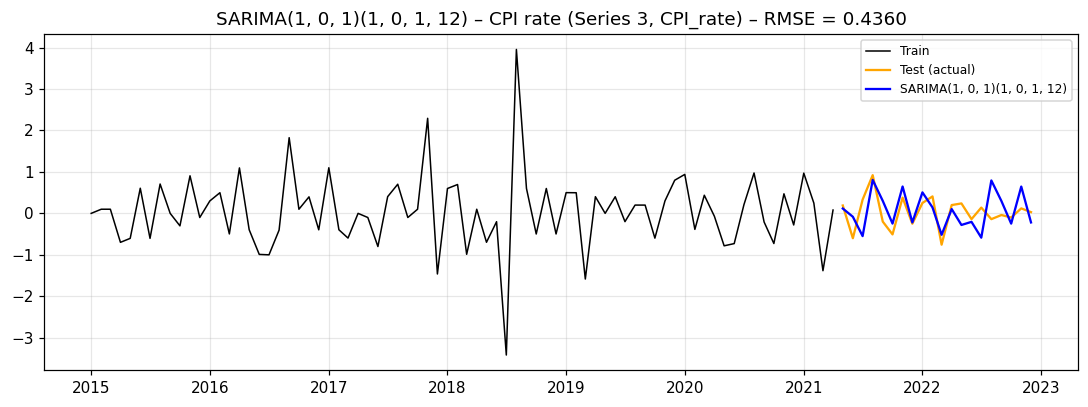

,series,order,seasonal_order,RMSE,AIC_train,converged,min_|root|,valid
0,CPI_rate,"(1, 0, 1)","(1, 0, 1, 12)",0.436,182.9273,True,1.0001,False


In [40]:
r, _ = sarima_one("CPI_rate", 1, 1, "p1_17_cpi_rate_sarima_example.png"); display(pd.DataFrame([r]).round(4))

**B2. CPI rate (Series 3) – grid over P, Q (D = 0, m = 12); lowest RMSE among valid fits = best model**

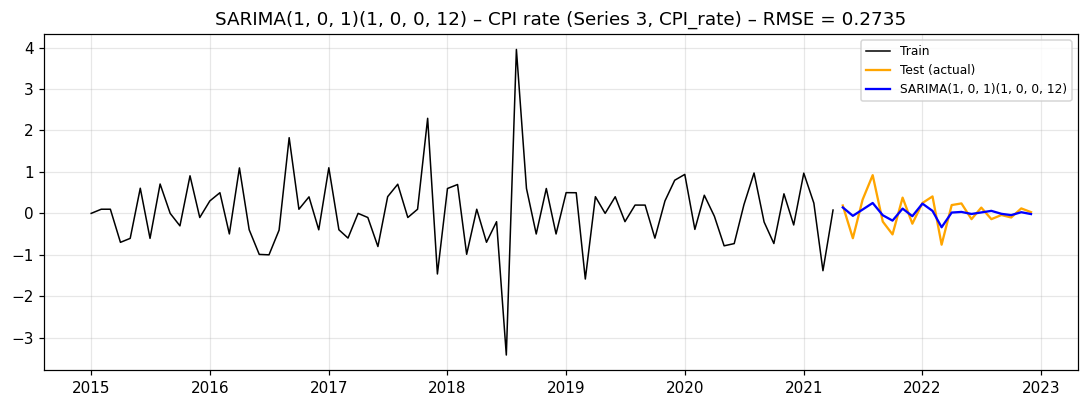

,series,order,seasonal_order,RMSE,AIC_train,converged,min_|root|,valid,ARIMA_RMSE,improvement_vs_ARIMA_%
0,CPI_rate,"(1, 0, 1)","(1, 0, 0, 12)",0.2735,190.3854,True,1.1254,True,0.3783,27.6994
1,CPI_rate,"(1, 0, 1)","(0, 0, 1, 12)",0.3038,191.9311,True,1.1649,True,0.3783,19.6980
2,CPI_rate,"(1, 0, 1)","(2, 0, 0, 12)",0.3645,185.5366,True,1.0357,True,0.3783,3.6498
3,CPI_rate,"(1, 0, 1)","(1, 0, 1, 12)",0.4360,182.9273,True,1.0001,False,0.3783,-15.2479
4,CPI_rate,"(1, 0, 1)","(0, 0, 2, 12)",0.4415,188.2800,True,1.0505,True,0.3783,-16.7049
5,CPI_rate,"(1, 0, 1)","(2, 0, 1, 12)",0.5061,183.3876,True,1.0001,False,0.3783,-33.7828
6,CPI_rate,"(1, 0, 1)","(1, 0, 2, 12)",0.5366,183.1590,True,1.0001,False,0.3783,-41.8455
7,CPI_rate,"(1, 0, 1)","(2, 0, 2, 12)",0.6162,184.6260,True,1.0009,False,0.3783,-62.8916


-> Best valid SARIMA by test RMSE: (1, 0, 1)(1, 0, 0, 12)  RMSE = 0.2735  (ARIMA: 0.3783; naive train mean: 0.3763)


In [41]:
sarima_grid("CPI_rate", "p1_17_cpi_rate_sarima_best.png")

**Comment on the result.** Seasonality is significant for the CPI rate too (ANOVA F = 3.69, p = 0.0003; Kruskal–Wallis p = 0.0001): the highest average month is August and the lowest is March, so m = 12 is justified. Four of the 8 combinations are valid and four are rejected because of roots on the unit circle ((1,0,1,12), (2,0,1,12), (1,0,2,12), (2,0,2,12)). The best valid model is **SARIMA(1,0,1)(1,0,0,12)** with RMSE = 0.2735, 27.7 % lower than ARIMA(1,0,1) (0.3783) and 27.3 % lower than the train-mean benchmark (0.3763). The result is sensitive to the seasonal order: the example (1,0,1,12) gives 0.436, worse than ARIMA, and (0,0,2,12) gives 0.4415. A seasonal AR(1) term at lag 12 gives the best valid result for both series, but the selection on 20 test points remains optimistic.

## Part 1 – summary table and conclusion

In [42]:
rows = []
for k in SER:
    b = BEST[k][0]; a = ARIMA_TT[k]; s = SARIMA_BEST[k]
    rows.append({"series": k, "d": D[k], "constant": TREND[k], "ARIMA(pO,dO,qO)": str(b["order"]), "AIC": b["AIC"], "selection": BEST[k][1],
                 "ARIMA test RMSE": a["RMSE"], "naive mean RMSE": a["naive_train_mean"], "naive last RMSE": a["naive_last_value"],
                 "best SARIMA": s["order"] + s["seasonal_order"], "SARIMA test RMSE": s["RMSE"]})
part1 = pd.DataFrame(rows); display(part1.round(4)); savecsv(part1, "p1_final_summary.csv")
print("CHECKPOINT: Part 1 completed.")

,series,d,constant,"ARIMA(pO,dO,qO)",AIC,selection,ARIMA test RMSE,naive mean RMSE,naive last RMSE,best SARIMA,SARIMA test RMSE
0,CPI,0,c,"(1, 0, 0)",203.1121,"OK (stable, lowest AIC)",0.2763,0.2798,0.4028,"(1, 0, 0)(1, 0, 0, 12)",0.2470
1,CPI_rate,0,n,"(1, 0, 1)",222.8275,"OK (stable, lowest AIC)",0.3783,0.3763,0.3802,"(1, 0, 1)(1, 0, 0, 12)",0.2735


CHECKPOINT: Part 1 completed.


**Part 1 conclusion.** Both series have no linear trend (p = 0.26 and 0.93) and are stationary in level (ADF p < 10⁻⁵, KPSS agrees), so d = 0. Series 1 behaves like an AR(1) process around 100.15 (ARIMA(1,0,0), AIC 203.1, stable coefficients); Series 3 follows an ARMA(1,1) without constant (ARIMA(1,0,1), AIC 222.8, stable coefficients). Out of sample the non-seasonal ARIMA models are barely better than a constant forecast (RMSE 0.276 vs 0.280 and 0.378 vs 0.376), which is expected for series that fluctuate randomly around a fixed mean. Calendar-month effects are significant (ANOVA p ≤ 0.0003), and a seasonal AR term with m = 12 lowers the test RMSE to 0.247 (CPI) and 0.274 (CPI rate); the improvement should be read with caution because the model was chosen on a 20-observation test set. Residual Ljung–Box tests (p < 0.01 at lag 24) confirm that structure remains unexplained by the non-seasonal models. Data note: Series 1 restarts every January, and 2018-07/08 contain a one-off drop and rebound that affects all statistics.

---
# Part 2. Detecting anomalies and change points in time series of Asian economic data
## 2.1 Introduction and data description
**Methodology.** *Anomaly detection* looks for individual observations that deviate markedly from the rest of a series (point-wise): the **Z-score** flags values with |z| > 3, **Isolation Forest** isolates observations that need few random splits to be separated. *Change-point detection* looks for the dates at which the statistical behaviour of the series (level / variance) shifts (segment-wise); here the **Pelt** algorithm with an RBF cost is used (`ruptures`). The two questions are different and are reported separately.

**Indicators** (Myanmar, annual): `ggdp` – Green Gross Domestic Product (Tổng sản phẩm trong nước xanh); `mil` – government spending on military (Chi tiêu chính phủ cho quân sự); `inf` – inflation rate (Tỉ lệ lạm phát); `fdi` – foreign investment (Vốn đầu tư nước ngoài); `gdp` – Gross Domestic Product (Tổng sản phẩm trong nước).

**Data array `Data02_01_Myanmar_C.csv`:** 32 annual rows (1990–2021), single country; columns `year`, `country`, `ggdp`, `mil`, `inf`, `fdi`, `gdp`. The file does not state units; `ggdp` is rounded to 2 significant digits (several consecutive equal values), `mil` takes values 0.7–4.3 and `inf` −0.1–57.1.

**Missing values** (table in the data-validation cell): `ggdp` 2020–2021, `inf` 2020–2021, `mil` 1995 and 2012–2017. They are **not imputed**: each series is analysed on its own available years, and plots leave a gap instead of joining across missing years.

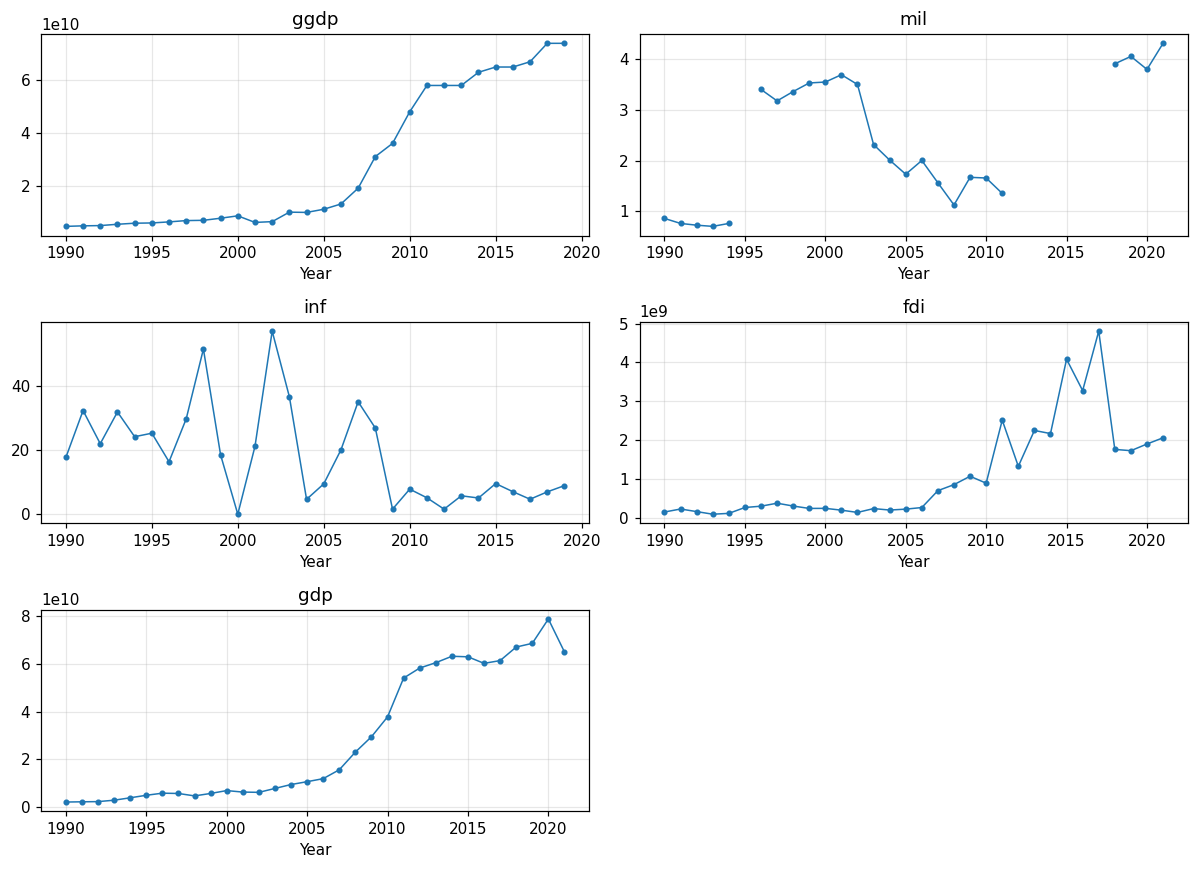

In [43]:
fig, axes = plt.subplots(3, 2, figsize=(11, 8)); axes = axes.ravel()
for ax, c in zip(axes, P2):
    ax.plot(df2["year"], df2[c], marker="o", ms=3, lw=1); ax.set_title(c); ax.set_xlabel("Year")
axes[-1].axis("off"); savefig("p2_overview.png")

## 2.2 Detecting anomalies
### A. Z-score method (threshold = 3)
$z_t=(x_t-\bar x)/s$, computed per series on its available years; an observation is an anomaly if $|z_t|>3$. With n observations the largest possible |z| is $(n-1)/\sqrt n$ (≈ 5.3 for n = 30), so the threshold is reachable but strict.

In [44]:
def series2(col):
    return df2[["year", col]].dropna().reset_index(drop=True)

def gap_plot(ax, col):
    ax.plot(df2["year"], df2[col], marker="o", ms=3, lw=1, color="tab:blue", label=col)   # NaN -> gap in the line
    ax.set_xlabel("Year"); ax.set_ylabel(col)

Z_RES = {}
def run_zscore(col, fname):
    s = series2(col); mu, sd = s[col].mean(), s[col].std()
    s["z"] = (s[col] - mu) / sd
    flagged = s[s["z"].abs() > Z_THRESHOLD]
    top = s.loc[s["z"].abs().sort_values(ascending=False).index].head(3)
    fig, ax = plt.subplots(figsize=(9, 3.6)); gap_plot(ax, col)
    ax.axhline(mu, color="grey", ls="--", lw=.8); ax.axhline(mu + Z_THRESHOLD * sd, color="red", ls=":", lw=1, label=f"mean ± {Z_THRESHOLD} sd")
    ax.axhline(mu - Z_THRESHOLD * sd, color="red", ls=":", lw=1)
    if not flagged.empty: ax.scatter(flagged["year"], flagged[col], color="red", zorder=5, label="anomaly")
    ax.set_title(f"Z-score – {col} (threshold = {Z_THRESHOLD})"); ax.legend(fontsize=8); savefig(fname)
    print(f"n = {len(s)} | mean = {mu:.4g} | sd = {sd:.4g} | max |z| = {top['z'].abs().iloc[0]:.2f} (year {int(top['year'].iloc[0])})")
    print("Largest |z|:", {int(y): round(z, 2) for y, z in zip(top["year"], top["z"])})
    print("Anomalies (|z| > %g):" % Z_THRESHOLD, flagged[["year", col, "z"]].round(3).to_dict("records") or "none")
    Z_RES[col] = {"series": col, "n": len(s), "max_abs_z": float(top["z"].abs().iloc[0]), "year_of_max": int(top["year"].iloc[0]),
                  "n_flagged": len(flagged), "flagged_years": flagged["year"].astype(int).tolist(),
                  "years_|z|>2": s.loc[s["z"].abs() > 2, "year"].astype(int).tolist()}

**A1. Series 1: ggdp – Code / Result**

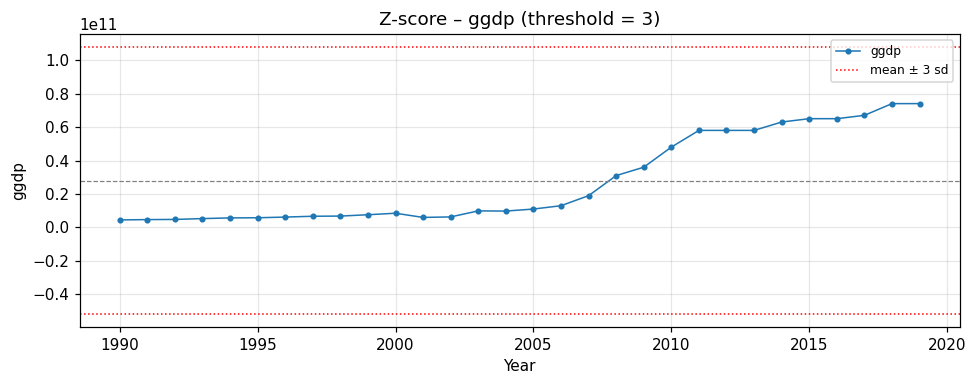

n = 30 | mean = 2.795e+10 | sd = 2.653e+10 | max |z| = 1.74 (year 2018)
Largest |z|: {2018: 1.74, 2019: 1.74, 2017: 1.47}
Anomalies (|z| > 3): none


In [45]:
run_zscore("ggdp", "p2_A1_ggdp_zscore.png")

**Comment on the result.** No anomaly: the largest |z| is 1.74 (2018 and 2019, both 7.4×10¹⁰, a tie because ggdp is rounded). The series grows slowly until 2005 and fast afterwards, so the highest values are the most recent ones, but they remain within 1.74 sd of the mean (n = 30, 2020–2021 missing). The Z-score does not take the time order into account, so it cannot flag a growing level.

**A2. Series 2: mil – Code / Result**

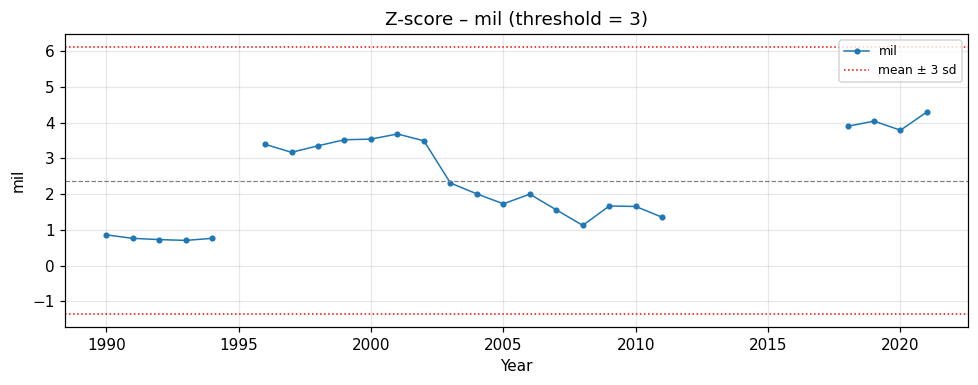

n = 25 | mean = 2.378 | sd = 1.242 | max |z| = 1.55 (year 2021)
Largest |z|: {2021: 1.55, 1993: -1.35, 2019: 1.34}
Anomalies (|z| > 3): none


In [46]:
run_zscore("mil", "p2_A2_mil_zscore.png")

**Comment on the result.** No anomaly: the largest |z| is 1.55 (2021, 4.30) followed by −1.35 (1993). With n = 25 (7 years missing) and a mean of 2.38 (sd 1.24), no year is extreme relative to the others. The big jump between 1994 and 1996 is a level shift, not a single outlier, so it is addressed by change-point detection.

**A3. Series 3: inf – Code / Result**

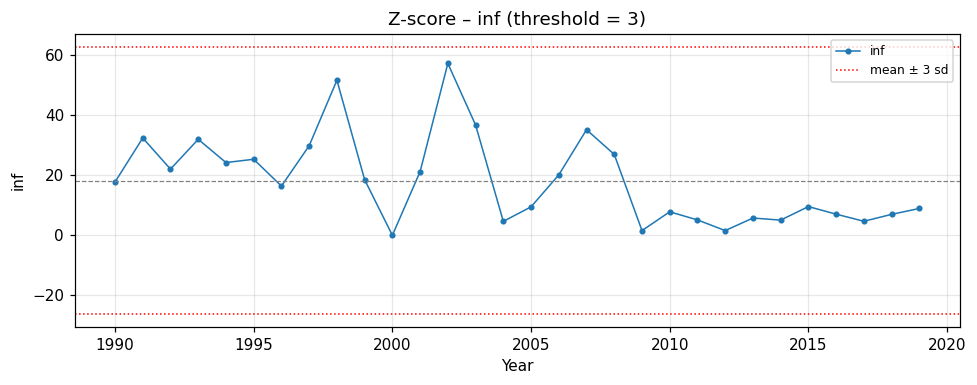

n = 30 | mean = 18.07 | sd = 14.77 | max |z| = 2.64 (year 2002)
Largest |z|: {2002: 2.64, 1998: 2.26, 2003: 1.25}
Anomalies (|z| > 3): none


In [47]:
run_zscore("inf", "p2_A3_inf_zscore.png")

**Comment on the result.** No point exceeds the threshold, but inflation has the two largest deviations among the series: 2002 (57.07 %, z = 2.64) and 1998 (51.49 %, z = 2.26); all others are below 2 in absolute value (n = 30, 2020–2021 missing). Inflation was high and volatile in the 1990s and 2000s (mean 18.1 %, sd 14.8), which inflates the standard deviation and makes it harder to exceed 3 sd.

**A4. Series 4: fdi – Code / Result**

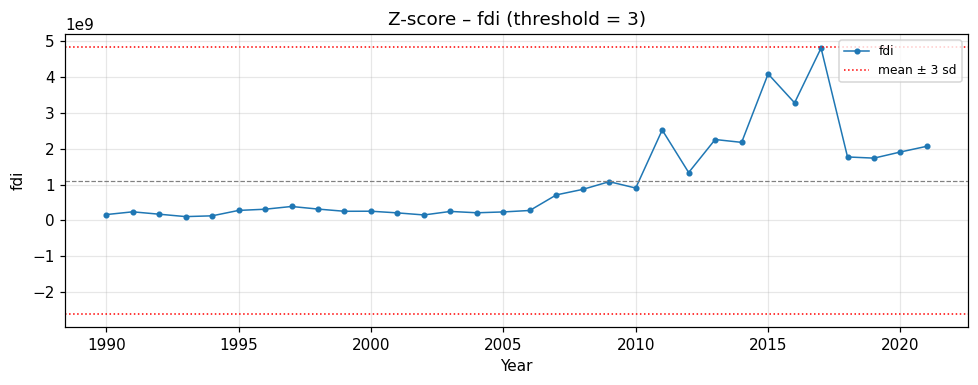

n = 32 | mean = 1.107e+09 | sd = 1.238e+09 | max |z| = 2.99 (year 2017)
Largest |z|: {2017: 2.99, 2015: 2.4, 2016: 1.75}
Anomalies (|z| > 3): none


In [48]:
run_zscore("fdi", "p2_A4_fdi_zscore.png")

**Comment on the result.** No point is flagged, but 2017 is on the border: z = 2.99 (4.80×10⁹, the maximum) just below 3, followed by 2015 (z = 2.40) and 2016 (1.75). A threshold of 2.5 would flag 2017 only and a threshold of 2 would flag 2015 and 2017, so the conclusion is sensitive to the threshold. The high values of 2015–2017 are the peak of the recent increase in foreign investment.

**A5. Series 5: gdp – Code / Result**

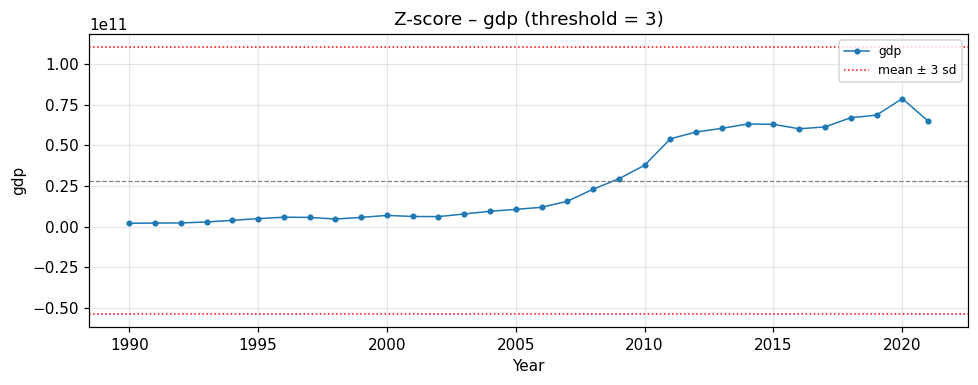

n = 32 | mean = 2.828e+10 | sd = 2.739e+10 | max |z| = 1.85 (year 2020)
Largest |z|: {2020: 1.85, 2019: 1.48, 2018: 1.42}
Anomalies (|z| > 3): none


In [49]:
run_zscore("gdp", "p2_A5_gdp_zscore.png")

**Comment on the result.** No anomaly: the largest |z| is 1.85 (2020, 7.89×10¹⁰), then 1.48 (2019) and 1.42 (2018). The series rises strongly from 2008 and is highest in 2020, but the 2021 value (6.51×10¹⁰) falls back, and no single year is beyond 3 sd. As for ggdp, a growing level is not captured by a time-independent z-score.

In [50]:
z_tbl = pd.DataFrame(Z_RES.values()); display(z_tbl); savecsv(z_tbl.astype(str), "p2_zscore_summary.csv")

,series,n,max_abs_z,year_of_max,n_flagged,flagged_years,years_|z|>2
0,ggdp,30,1.735651,2018,0,[],[]
1,mil,25,1.548498,2021,0,[],[]
2,inf,30,2.641048,2002,0,[],"[1998, 2002]"
3,fdi,32,2.986215,2017,0,[],"[2015, 2017]"
4,gdp,32,1.849231,2020,0,[],[]


### B. Isolation Forest method
`IsolationForest(contamination=0.05, random_state=42)` on the values of each series (one feature); label −1 = anomaly. `contamination` is a modelling assumption that fixes the share of flagged points (≈ 5 %) – it is **not** an estimate of the true anomaly rate. Two extra checks are printed: the five lowest anomaly scores (more negative = more isolated) and how often each year is flagged over 50 different random seeds (stability).

In [51]:
IF_RES = {}
def run_iforest(col, fname):
    s = series2(col); X = s[[col]].values
    m = IsolationForest(contamination=IF_CONTAMINATION, random_state=SEED).fit(X)
    s["label"], s["score"] = m.predict(X), m.decision_function(X)
    flagged = s[s["label"] == -1]
    cnt = pd.Series(0, index=s["year"], dtype=float)
    for sd in range(50):
        lab = IsolationForest(contamination=IF_CONTAMINATION, random_state=sd).fit_predict(X)
        cnt[s["year"][lab == -1].values] += 1
    stab = (cnt / 50).sort_values(ascending=False).head(4)
    fig, ax = plt.subplots(figsize=(9, 3.6)); gap_plot(ax, col)
    if not flagged.empty: ax.scatter(flagged["year"], flagged[col], color="red", zorder=5, label="Isolation Forest anomaly")
    ax.set_title(f"Isolation Forest – {col} (contamination = {IF_CONTAMINATION})"); ax.legend(fontsize=8); savefig(fname)
    print(f"n = {len(s)} -> flagged {len(flagged)} point(s) (seed {SEED}):")
    display(flagged[["year", col, "score"]].round(4).reset_index(drop=True))
    print("Five lowest scores:", {int(y): round(v, 3) for y, v in s.nsmallest(5, "score")[["year", "score"]].values})
    print("Share of 50 seeds in which the year is flagged:", {int(y): round(v, 2) for y, v in stab.items()})
    IF_RES[col] = {"series": col, "n": len(s), "flagged_years": flagged["year"].astype(int).tolist(),
                   "values": flagged[col].tolist(), "most_stable_year_share": float(stab.iloc[0])}

**B1. Series 1: ggdp – Code / Result**

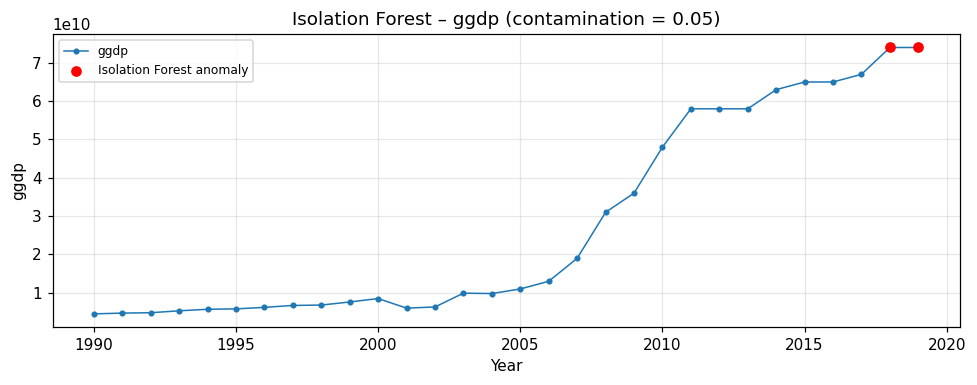

n = 30 -> flagged 2 point(s) (seed 42):


,year,ggdp,score
0,2018,7.400000e+10,-0.0077
1,2019,7.400000e+10,-0.0077


Five lowest scores: {2018: np.float64(-0.008), 2019: np.float64(-0.008), 2010: np.float64(0.009), 2007: np.float64(0.016), 2009: np.float64(0.02)}
Share of 50 seeds in which the year is flagged: {2010: 0.46, 2018: 0.42, 2019: 0.42, 2007: 0.16}


In [52]:
run_iforest("ggdp", "p2_B1_ggdp_iforest.png")

**Comment on the result.** Isolation Forest (seed 42) flags 2018 and 2019 (both 7.4×10¹⁰; identical values, so identical scores −0.0077), the two highest values of the series. This result is **not stable**: over 50 seeds the share of runs flagging each year is only 46 % for 2010, 42 % for 2018 and 42 % for 2019. The flagged years are therefore extremes of a rising level (and tied values), not reliable anomalies.

**B2. Series 2: mil – Code / Result**

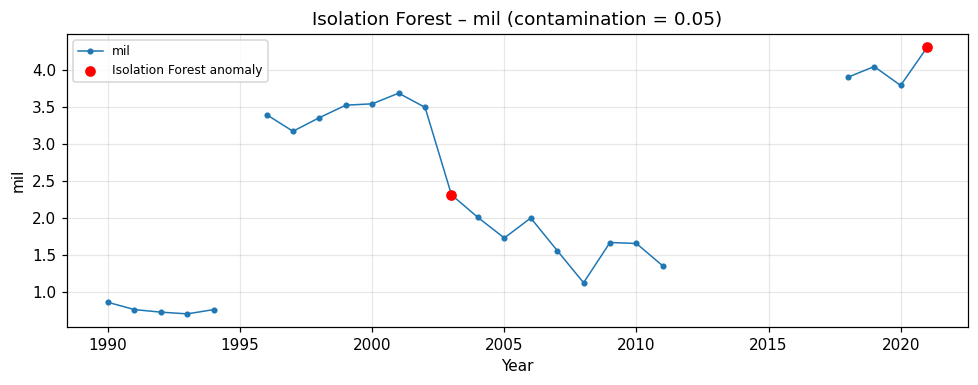

n = 25 -> flagged 2 point(s) (seed 42):


,year,mil,score
0,2003,2.3137,-0.0059
1,2021,4.3014,-0.0736


Five lowest scores: {2021: np.float64(-0.074), 2003: np.float64(-0.006), 2008: np.float64(0.024), 1993: np.float64(0.026), 1997: np.float64(0.032)}
Share of 50 seeds in which the year is flagged: {2021: 1.0, 2003: 0.82, 2008: 0.1, 2019: 0.04}


In [53]:
run_iforest("mil", "p2_B2_mil_iforest.png")

**Comment on the result.** Flagged: 2021 (4.30, score −0.074, flagged in 100 % of the seeds) and 2003 (2.31, score −0.006, 82 % of the seeds). 2021 is the highest value of the series and clearly isolated. 2003 is the first year after the fall from 3.49 (2002) and lies in a sparse region between the values around 1.7–2.0 and 3.4–3.7; it is a moderately stable flag.

**B3. Series 3: inf – Code / Result**

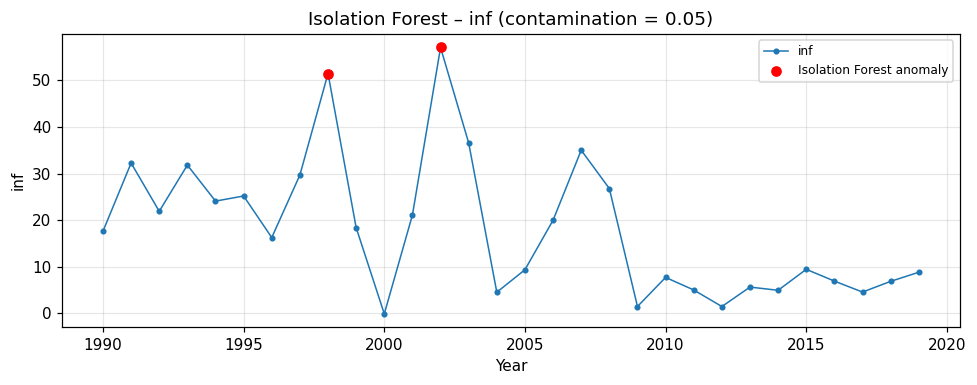

n = 30 -> flagged 2 point(s) (seed 42):


,year,inf,score
0,1998,51.4875,-0.0250
1,2002,57.0745,-0.0732


Five lowest scores: {2002: np.float64(-0.073), 1998: np.float64(-0.025), 2000: np.float64(0.031), 2003: np.float64(0.115), 2007: np.float64(0.128)}
Share of 50 seeds in which the year is flagged: {2002: 1.0, 1998: 1.0, 1992: 0.0, 1993: 0.0}


In [54]:
run_iforest("inf", "p2_B3_inf_iforest.png")

**Comment on the result.** Flagged: 2002 (57.07 %, score −0.073) and 1998 (51.49 %, −0.025), in 100 % of the 50 seeds. These are the two highest inflation rates, the same two years with the largest z-scores (2.64 and 2.26), so the two methods agree on which years are the most atypical even though the Z-score threshold was not exceeded.

**B4. Series 4: fdi – Code / Result**

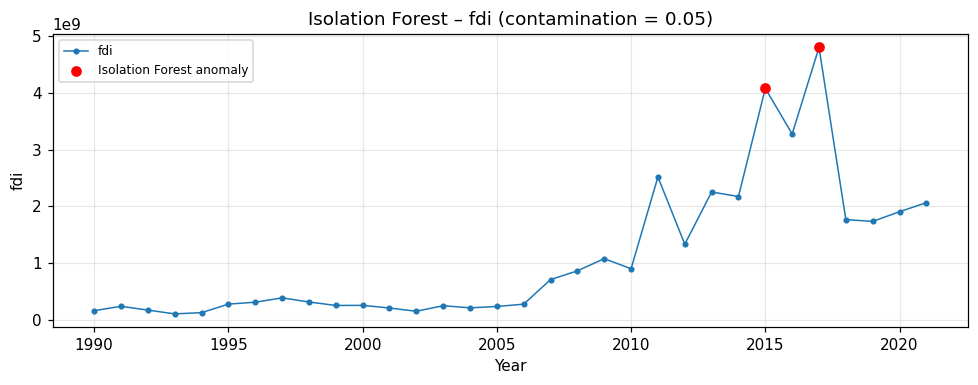

n = 32 -> flagged 2 point(s) (seed 42):


,year,fdi,score
0,2015,4.083839e+09,-0.0228
1,2017,4.804272e+09,-0.1060


Five lowest scores: {2017: np.float64(-0.106), 2015: np.float64(-0.023), 2016: np.float64(0.019), 2011: np.float64(0.074), 2012: np.float64(0.103)}
Share of 50 seeds in which the year is flagged: {2015: 1.0, 2017: 1.0, 1990: 0.0, 1991: 0.0}


In [55]:
run_iforest("fdi", "p2_B4_fdi_iforest.png")

**Comment on the result.** Flagged: 2017 (4.80×10⁹, score −0.106) and 2015 (4.08×10⁹, −0.023), in 100 % of the seeds. They are the two largest values and coincide with the two largest z-scores (2.99 and 2.40). The peak of 2015–2017 stands out from the earlier years, when fdi was below 3×10⁹ for all years.

**B5. Series 5: gdp – Code / Result**

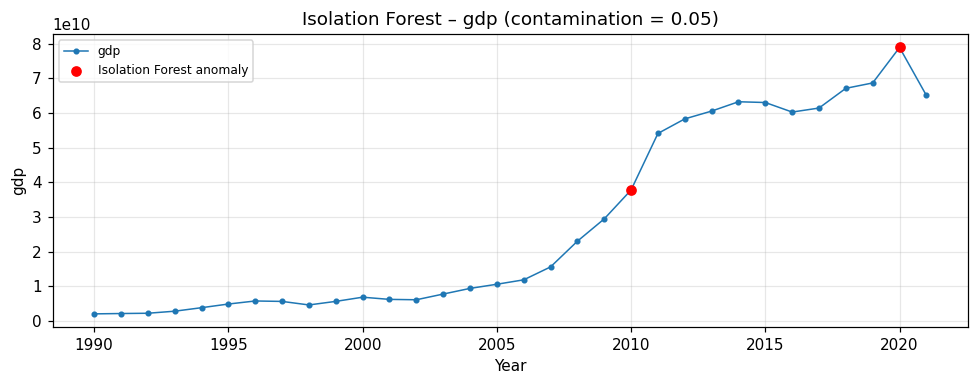

n = 32 -> flagged 2 point(s) (seed 42):


,year,gdp,score
0,2010,37796052939,-0.0110
1,2020,78930257227,-0.1165


Five lowest scores: {2020: np.float64(-0.117), 2010: np.float64(-0.011), 2009: np.float64(0.009), 2008: np.float64(0.024), 2011: np.float64(0.047)}
Share of 50 seeds in which the year is flagged: {2020: 1.0, 2010: 1.0, 1990: 0.0, 1991: 0.0}


In [56]:
run_iforest("gdp", "p2_B5_gdp_iforest.png")

**Comment on the result.** Flagged: 2020 (7.89×10¹⁰, score −0.117) and 2010 (3.78×10¹⁰, score −0.011), both in 100 % of the seeds. 2020 is the maximum. 2010 is flagged because it falls in the sparse region between the values of 2009 (2.9×10¹⁰) and 2011 (5.4×10¹⁰), during the fast growth phase; this is the same year at which the change-point method detects a break.

**Comparison of the two anomaly methods**

In [57]:
cmp_rows = [{"series": c, "Z-score years": Z_RES[c]["flagged_years"], "Isolation Forest years": IF_RES[c]["flagged_years"],
             "overlap": sorted(set(Z_RES[c]["flagged_years"]) & set(IF_RES[c]["flagged_years"]))} for c in P2]
cmp_tbl = pd.DataFrame(cmp_rows); display(cmp_tbl)
if_long = pd.DataFrame([{"series": c, "year": y, "value": v} for c in P2 for y, v in zip(IF_RES[c]["flagged_years"], IF_RES[c]["values"])])
savecsv(cmp_tbl.astype(str), "p2_anomaly_comparison.csv"); savecsv(if_long, "p2_isolation_forest_flagged.csv")

,series,Z-score years,Isolation Forest years,overlap
0,ggdp,[],"[2018, 2019]",[]
1,mil,[],"[2003, 2021]",[]
2,inf,[],"[1998, 2002]",[]
3,fdi,[],"[2015, 2017]",[]
4,gdp,[],"[2010, 2020]",[]


**Comment on the result.** The Z-score method (|z| > 3) flags nothing in any series, whereas Isolation Forest flags exactly two points per series (about 5 % of 25–32 points, as fixed by `contamination = 0.05`), so there is no overlap. The two results are compatible rather than contradictory: for inf, fdi and gdp the Isolation Forest years are stable across 50 seeds and are the same years that have the largest |z| (inf 2002/1998, fdi 2017/2015), while for ggdp (and partly mil) the flags are unstable and only reflect the highest level of a growing series. Isolation Forest returns "the most atypical 5 %", not statistically significant outliers; the only series with a Z-score close to the threshold is fdi 2017 (z = 2.99).

## 2.3 Change point detection
`ruptures.Pelt(model="rbf")` with penalty = 10 (primary setting). The reported year is the **first year of the new regime** (ruptures returns the index where a new segment starts). Because the result depends on the penalty (larger penalty ⇒ fewer breakpoints), the breakpoints found for pen ∈ {1, 2, 3, 5, 10} are also listed as a sensitivity check.

In [58]:
CP_RES = {}
def run_changepoint(col, fname):
    s = series2(col); X = s[[col]].values.astype(float)
    algo = rpt.Pelt(model=CP_MODEL).fit(X)
    bk = lambda pen: [i for i in algo.predict(pen=pen) if i < len(s)]
    sens = {pen: [int(s["year"][i]) for i in bk(pen)] for pen in CP_PEN_GRID}
    main = bk(CP_PEN); edges = [0] + main + [len(s)]
    seg = [{"segment": f"{int(s['year'][a])}-{int(s['year'][b-1])}", "n": b - a, "mean": float(s[col][a:b].mean()), "sd": float(s[col][a:b].std())}
           for a, b in zip(edges[:-1], edges[1:])]
    fig, ax = plt.subplots(figsize=(9, 3.6)); gap_plot(ax, col)
    for i in main: ax.axvline(s["year"][i] - 0.5, color="red", ls="--", lw=1.2, label="change point")
    h, l = ax.get_legend_handles_labels(); u = dict(zip(l, h)); ax.legend(u.values(), u.keys(), fontsize=8)
    ax.set_title(f"Change points – {col} (Pelt, {CP_MODEL}, pen = {CP_PEN})"); savefig(fname)
    print(f"n = {len(s)} | change point(s) at pen = {CP_PEN} (first year of new regime):", [int(s['year'][i]) for i in main] or "none")
    display(pd.DataFrame(seg).round(3))
    print("Sensitivity to the penalty:", sens)
    CP_RES[col] = {"series": col, "n": len(s), f"pen={CP_PEN}": sens[CP_PEN], **{f"pen={p}": v for p, v in sens.items() if p != CP_PEN}}

**C1. Series 1: ggdp – Code / Result**

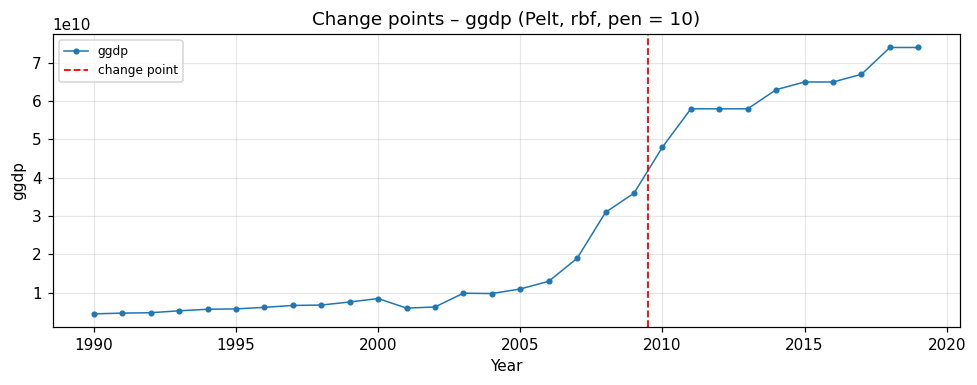

n = 30 | change point(s) at pen = 10 (first year of new regime): [2010]


,segment,n,mean,sd
0,1990-2009,20,1.043000e+10,8.648766e+09
1,2010-2019,10,6.300000e+10,7.930252e+09


Sensitivity to the penalty: {1: [2005, 2010], 2: [2010], 3: [2010], 5: [2010], 10: [2010]}


In [59]:
run_changepoint("ggdp", "p2_C1_ggdp_changepoint.png")

**Comment on the result.** At penalty 10 one change point is found in **2010**: the mean level increases from 1.04×10¹⁰ (1990–2009) to 6.30×10¹⁰ (2010–2019), about six times higher. It is robust: 2010 is detected for every penalty from 2 to 10, and penalty 1 adds 2005 (start of the acceleration). The break marks the transition from low growth to a high-level regime; the data cannot tell why.

**C2. Series 2: mil – Code / Result**

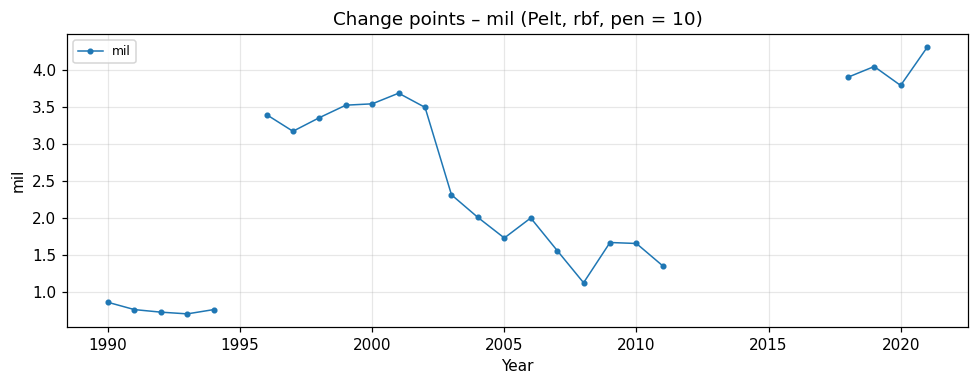

n = 25 | change point(s) at pen = 10 (first year of new regime): none


,segment,n,mean,sd
0,1990-2021,25,2.378,1.242


Sensitivity to the penalty: {1: [1996, 2006, 2011], 2: [1996, 2006, 2011], 3: [1996], 5: [], 10: []}


In [60]:
run_changepoint("mil", "p2_C2_mil_changepoint.png")

**Comment on the result.** No change point at penalty 10 or 5, but a visible level shift exists: with penalty ≤ 3 a break appears in **1996** (from about 0.75 in 1990–94 to about 3.4), and with penalty ≤ 2 also 2006 and 2011 (the decline from about 3.5 to about 1.4). The 1996 break falls across the missing year 1995, so its exact date is only known to be between 1994 and 1996; the gap 2012–2017 also prevents any conclusion for that period. "No change point at penalty 10" should not be read as "stable series".

**C3. Series 3: inf – Code / Result**

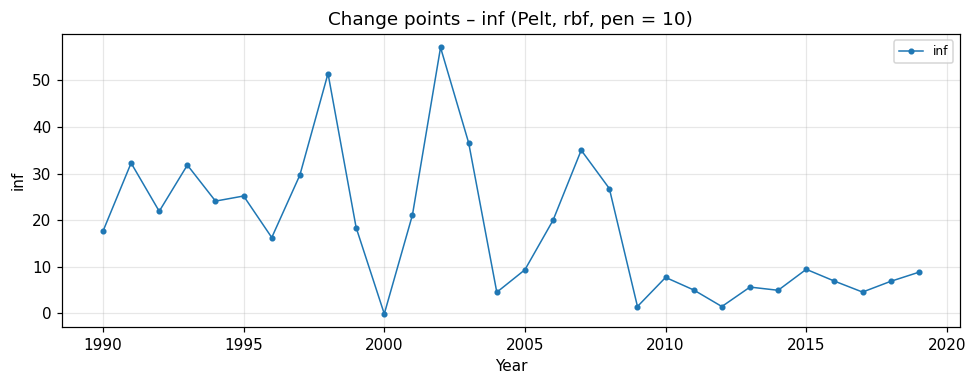

n = 30 | change point(s) at pen = 10 (first year of new regime): none


,segment,n,mean,sd
0,1990-2019,30,18.07,14.768


Sensitivity to the penalty: {1: [2000, 2010], 2: [2010], 3: [2010], 5: [], 10: []}


In [61]:
run_changepoint("inf", "p2_C3_inf_changepoint.png")

**Comment on the result.** No change point at penalty 10 and 5. Lower penalties give **2010** (penalty 2 and 3) and also 2000 (penalty 1): inflation is high and volatile (up to 57 %) until 2008–2009 and mostly below 10 % afterwards. The break is therefore a change of regime in level and volatility, but it is less pronounced than for gdp and is only found when a small penalty is accepted.

**C4. Series 4: fdi – Code / Result**

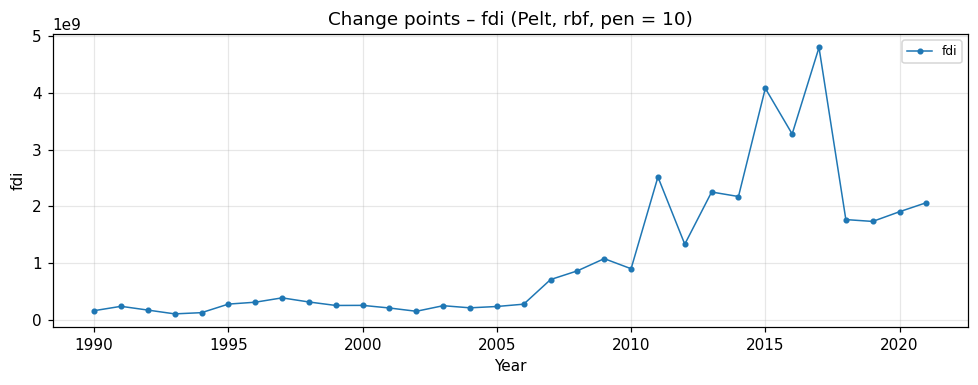

n = 32 | change point(s) at pen = 10 (first year of new regime): none


,segment,n,mean,sd
0,1990-2021,32,1.106545e+09,1.238266e+09


Sensitivity to the penalty: {1: [2005, 2010], 2: [2010], 3: [2010], 5: [2010], 10: []}


In [62]:
run_changepoint("fdi", "p2_C4_fdi_changepoint.png")

**Comment on the result.** No change point at penalty 10, but **2010** appears for penalties 2 to 5 and 2005 is added at penalty 1: foreign investment is below 1.1×10⁹ until 2010 and then rises with large fluctuations (up to 4.8×10⁹ in 2017). The size of the variation after 2010 makes this a plausible break that the strict penalty 10 does not accept.

**C5. Series 5: gdp – Code / Result**

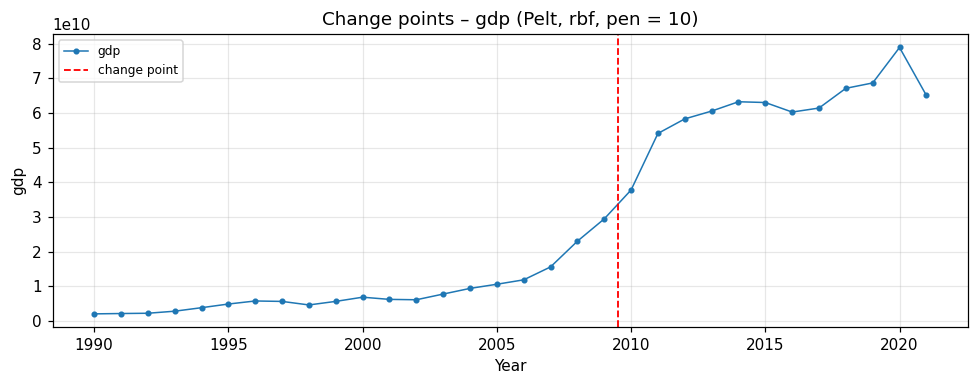

n = 32 | change point(s) at pen = 10 (first year of new regime): [2010]


,segment,n,mean,sd
0,1990-2009,20,8.319315e+09,7.101347e+09
1,2010-2021,12,6.156012e+10,9.698410e+09


Sensitivity to the penalty: {1: [2005, 2010], 2: [2010], 3: [2010], 5: [2010], 10: [2010]}


In [63]:
run_changepoint("gdp", "p2_C5_gdp_changepoint.png")

**Comment on the result.** One change point at penalty 10: **2010**, with the mean rising from 8.3×10⁹ (1990–2009) to 6.16×10¹⁰ (2010–2021). Like ggdp, it is robust (detected for penalties 2–10; penalty 1 adds 2005). ggdp and gdp share the same break year, and the lower-penalty results for fdi and inf also point to 2010, so several indicators change regime around the same time. The algorithm identifies *when* the statistical behaviour changes, not the cause.

In [64]:
cp_tbl = pd.DataFrame(CP_RES.values()); display(cp_tbl); savecsv(cp_tbl.astype(str), "p2_changepoint_summary.csv")
print("CHECKPOINT: Part 2 completed.")

,series,n,pen=10,pen=1,pen=2,pen=3,pen=5
0,ggdp,30,[2010],"[2005, 2010]",[2010],[2010],[2010]
1,mil,25,[],"[1996, 2006, 2011]","[1996, 2006, 2011]",[1996],[]
2,inf,30,[],"[2000, 2010]",[2010],[2010],[]
3,fdi,32,[],"[2005, 2010]",[2010],[2010],[2010]
4,gdp,32,[2010],"[2005, 2010]",[2010],[2010],[2010]


CHECKPOINT: Part 2 completed.


**Part 2 conclusion.** The strict Z-score rule (|z| > 3) finds no anomaly in ggdp, mil, inf, fdi or gdp; the closest cases are fdi 2017 (z = 2.99), inf 2002 (2.64) and inf 1998 (2.26). Isolation Forest with 5 % contamination always flags two points per series; for inf, fdi and gdp these are stable across seeds and coincide with the largest deviations, whereas for ggdp the flags are unstable and mostly the highest levels of a growing series. Change-point detection (Pelt, RBF, penalty 10) finds one break in **2010** for both ggdp and gdp (the mean level rises about six-fold for ggdp and seven-fold for gdp). With smaller penalties fdi and inf also break around 2010 and mil in 1996, so the result depends on the penalty and should be reported with its sensitivity. Missing values (mil: 7 years, ggdp and inf: 2 years) were not imputed, which limits conclusions for mil around 1995 and 2012–2017 and for the 2020–2021 values of ggdp and inf.

---
## Output inventory

In [65]:
print("Tables in ./results:"); [print("  ", f) for f in sorted(os.listdir(RES_DIR))]
print("\nFigures in ./figures:"); [print("  ", f) for f in sorted(os.listdir(FIG_DIR))]

Tables in ./results:
   data_summary.csv
   p1_arima_all_coefficient_CIs.csv
   p1_arima_grid.csv
   p1_arima_rmse_loop.csv
   p1_final_summary.csv
   p1_forecast_CPI.csv
   p1_forecast_CPI_rate.csv
   p1_ljung_box.csv
   p1_order_limits.csv
   p1_seasonality_tests.csv
   p1_stationarity.csv
   p1_trend_check.csv
   p2_anomaly_comparison.csv
   p2_changepoint_summary.csv
   p2_isolation_forest_flagged.csv
   p2_zscore_summary.csv
   part2_missing_values.csv

Figures in ./figures:
   p1_15_cpi_forecast.png
   p1_15_cpi_rate_forecast.png
   p1_16_cpi_arima_tt.png
   p1_16_cpi_rate_arima_tt.png
   p1_17_cpi_rate_sarima_best.png
   p1_17_cpi_rate_sarima_example.png
   p1_17_cpi_sarima_best.png
   p1_17_cpi_sarima_example.png
   p1_17_monthly_means.png
   p1_A1_cpi_plot.png
   p1_A2_cpi_rate_plot.png
   p1_C1_cpi_acf.png
   p1_C2_cpi_rate_acf.png
   p1_D1_cpi_pacf.png
   p1_D2_cpi_rate_pacf.png
   p2_A1_ggdp_zscore.png
   p2_A2_mil_zscore.png
   p2_A3_inf_zscore.png
   p2_A4_fdi_zscore.png


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]